Start

In [ ]:
import pandas as pd

# read the CSV with tick data from broker
nq = pd.read_csv('GC_HTC_Updated.csv', sep='\t')
print(type(nq))
print(nq.shape)
print(nq.head())


<class 'pandas.core.frame.DataFrame'>
(51971850, 7)
       <DATE>        <TIME>    <BID>    <ASK>  <LAST>  <VOLUME>  <FLAGS>
0  2025.01.02  01:00:00.286  2625.38  2628.39     NaN       NaN      102
1  2025.01.02  01:00:00.489  2625.30  2628.05     NaN       NaN      102
2  2025.01.02  01:00:00.603  2625.72  2625.80     NaN       NaN      102
3  2025.01.02  01:00:00.696  2625.33  2625.60     NaN       NaN      102
4  2025.01.02  01:00:00.771  2625.49  2625.57     NaN       NaN      102


In [5]:
# Further clean: forward-fill Bid/Ask, drop unwanted cols, round and save final CSV
# Filter to: dates >= 2024-12-01 AND US trading hours (mapped to America/New_York 09:30-16:00)
# Assumes `nq` is already loaded and has separate date and time columns (we will NOT store combined datetimes)
cols_needed = ['<DATE>', '<TIME>', '<BID>', '<ASK>']
# If columns were cleaned earlier, check both variants
for c in ['DATE','TIME','BID','ASK']:
    if c in nq.columns and ('<' + c + '>') not in nq.columns:
        cols_needed = ['DATE','TIME','BID','ASK']
        break

# Ensure Bid/Ask numeric
for col in ['<BID>','<ASK>','BID','ASK']:
    if col in nq.columns:
        nq[col] = pd.to_numeric(nq[col], errors='coerce')

# Identify which date/time columns to use
date_col = 'DATE' if 'DATE' in nq.columns else ('<DATE>' if '<DATE>' in nq.columns else None)
time_col = 'TIME' if 'TIME' in nq.columns else ('<TIME>' if '<TIME>' in nq.columns else None)

# Debug: initial shape
initial_rows = len(nq)
print(f'Initial rows: {initial_rows}')

# Filter by date: keep only data from 2024-12-01 onwards (applies to dataset-local date column)
if date_col:
    nq[date_col] = pd.to_datetime(nq[date_col], errors='coerce')
    before_date_rows = len(nq)
    nq = nq[nq[date_col] >= pd.Timestamp('2024-12-01')]
    after_date_rows = len(nq)
    print(f'Rows before date filter: {before_date_rows} -> after date filter: {after_date_rows}')
else:
    print('Warning: no date column found; skipping date filter')

# Timezone-aware trading-hours filter (temporary combined datetime for filtering only)
if time_col and date_col:
    nq[time_col] = nq[time_col].astype(str).str.strip()
    # Build temporary combined datetime for filtering only
    combined = pd.to_datetime(nq[date_col].dt.strftime('%Y-%m-%d') + ' ' + nq[time_col], errors='coerce')

    # Localize/convert timezones. Dataset timezone assumed to be Europe/Bucharest (UTC+2/UTC+3 depending on DST).
    dataset_tz = 'Europe/Bucharest'
    target_tz = 'America/New_York'

    # Localize naive datetimes then convert to target tz
    combined = combined.dt.tz_localize(dataset_tz, ambiguous='NaT', nonexistent='shift_forward')
    combined_ny = combined.dt.tz_convert(target_tz)

    # Filter for NY trading hours 09:30:00 - 16:00:00 (inclusive)
    from datetime import time as dtime
    times_ny = combined_ny.dt.time
    mask_time = times_ny >= dtime(9, 30)
    mask_time &= times_ny <= dtime(16, 0)

    before_time_rows = len(nq)
    nq = nq[mask_time.fillna(False).values]
    after_time_rows = len(nq)
    print(f'Rows before time filter: {before_time_rows} -> after time filter: {after_time_rows} (NY hours 09:30-16:00)')

    # Drop temporary variables (we never add combined to final dataframe)
    del combined, combined_ny, times_ny, mask_time
else:
    print('Warning: missing date or time column; skipping time-of-day filter')

# Forward fill Bid/Ask
nq = nq.fillna(method='ffill')

# Keep only Date, Time, Bid, Ask (prefer cleaned names without angle brackets)
prefer_cols = []
if 'DATE' in nq.columns and 'TIME' in nq.columns:
    prefer_cols = ['DATE','TIME']
elif '<DATE>' in nq.columns and '<TIME>' in nq.columns:
    prefer_cols = ['<DATE>','<TIME>']

bid_col = 'BID' if 'BID' in nq.columns else ('<BID>' if '<BID>' in nq.columns else None)
ask_col = 'ASK' if 'ASK' in nq.columns else ('<ASK>' if '<ASK>' in nq.columns else None)

final_cols = []
if prefer_cols:
    final_cols.extend(prefer_cols)
if bid_col:
    final_cols.append(bid_col)
if ask_col:
    final_cols.append(ask_col)

# Safety: ensure we have at least Date and Time in final_cols before indexing
if len(final_cols) < 2:
    raise ValueError(f'Not enough columns to select Date and Time. final_cols={final_cols}')

# Select and rename to Date, Time, Bid, Ask
clean_df = nq[final_cols].copy()
rename_map = {}
if len(final_cols) >= 1 and final_cols[0] in ['<DATE>','DATE']:
    rename_map[final_cols[0]] = 'Date'
if len(final_cols) >= 2 and final_cols[1] in ['<TIME>','TIME']:
    rename_map[final_cols[1]] = 'Time'
if bid_col:
    rename_map[bid_col] = 'Bid'
if ask_col:
    rename_map[ask_col] = 'Ask'
clean_df = clean_df.rename(columns=rename_map)

# Round Bid/Ask to 3 decimals
if 'Bid' in clean_df.columns:
    clean_df['Bid'] = clean_df['Bid'].round(3)
if 'Ask' in clean_df.columns:
    clean_df['Ask'] = clean_df['Ask'].round(3)

# Drop rows where both Bid and Ask are NaN
clean_df = clean_df.dropna(subset=['Bid','Ask'], how='all')

# Save final cleaned CSV
# out_final = 'icm_nq_final_cleaned.csv'
out_final = 'HTC_GC_final_cleaned.csv'
clean_df.to_csv(out_final, index=False)
print(f'✓ Saved final cleaned CSV: {out_final} — shape: {clean_df.shape}')


Initial rows: 51971850
Rows before date filter: 51971850 -> after date filter: 51971850
Rows before time filter: 51971850 -> after time filter: 18844917 (NY hours 09:30-16:00)


C:\Users\lucca\AppData\Local\Temp\ipykernel_11960\2412955162.py:65: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  nq = nq.fillna(method='ffill')


✓ Saved final cleaned CSV: HTC_GC_final_cleaned.csv — shape: (18844917, 4)


In [6]:
# read the CSV from the notebook's working directory (file is tab-separated)

import pandas as pd

nqc = pd.read_csv('icm_nq_final_cleaned.csv')
print(type(nqc))
print(nqc.shape)
print(nqc.head())

# nqc.describe()

<class 'pandas.core.frame.DataFrame'>
(39553565, 4)
         Date          Time       Bid       Ask
0  2024-12-02  16:30:00.004  21001.97  21002.97
1  2024-12-02  16:30:00.222  21001.72  21002.72
2  2024-12-02  16:30:00.228  21001.47  21002.47
3  2024-12-02  16:30:00.402  21000.97  21001.97
4  2024-12-02  16:30:00.618  21001.72  21002.72


In [7]:
# create midprice column for classification/volatility proxies
nqc['Mid'] = (nqc['Bid'] + nqc['Ask']) / 2

print(nqc.head())

         Date          Time       Bid       Ask       Mid
0  2024-12-02  16:30:00.004  21001.97  21002.97  21002.47
1  2024-12-02  16:30:00.222  21001.72  21002.72  21002.22
2  2024-12-02  16:30:00.228  21001.47  21002.47  21001.97
3  2024-12-02  16:30:00.402  21000.97  21001.97  21001.47
4  2024-12-02  16:30:00.618  21001.72  21002.72  21002.22


In [8]:
import numpy as np

nqc['PrevMidPrice'] = nqc['Mid'].shift(1)

# Classify volume: buy when midprice increases, sell when it decreases
# For neutral volumes (no price change), inherit the previous tick's classification
nqc['Direction'] = 0.0
nqc.loc[nqc['Mid'] > nqc['PrevMidPrice'], 'Direction'] = 1  # Buy
nqc.loc[nqc['Mid'] < nqc['PrevMidPrice'], 'Direction'] = -1  # Sell

# Forward fill direction for neutral volumes (inherit previous trade direction)
# Also backward fill for first row if needed
nqc['Direction'] = nqc['Direction'].replace(0, np.nan).ffill().bfill()

# Assign back to BuyVolume and SellVolume
nqc['BuyVolume'] = (nqc['Direction'] == 1).astype(float)
nqc['SellVolume'] = (nqc['Direction'] == -1).astype(float)

print(nqc['Direction'].value_counts())
print('BuyVolume sum:', nqc['BuyVolume'].sum(), 'SellVolume sum:', nqc['SellVolume'].sum())

Direction
 1.0    19866045
-1.0    19687520
Name: count, dtype: int64
BuyVolume sum: 19866045.0 SellVolume sum: 19687520.0


In [9]:

print(nqc.head())

         Date          Time       Bid       Ask       Mid  PrevMidPrice  \
0  2024-12-02  16:30:00.004  21001.97  21002.97  21002.47           NaN   
1  2024-12-02  16:30:00.222  21001.72  21002.72  21002.22      21002.47   
2  2024-12-02  16:30:00.228  21001.47  21002.47  21001.97      21002.22   
3  2024-12-02  16:30:00.402  21000.97  21001.97  21001.47      21001.97   
4  2024-12-02  16:30:00.618  21001.72  21002.72  21002.22      21001.47   

   Direction  BuyVolume  SellVolume  
0       -1.0        0.0         1.0  
1       -1.0        0.0         1.0  
2       -1.0        0.0         1.0  
3       -1.0        0.0         1.0  
4        1.0        1.0         0.0  


In [9]:
# Calculate cumulative volume for each day
daily_volume = nqc.groupby('Date')[['BuyVolume', 'SellVolume']].sum().reset_index()
daily_volume['TotalVolume'] = daily_volume['BuyVolume'] + daily_volume['SellVolume']
daily_volume.columns = ['Date', 'DailyBuyVolume', 'DailySellVolume', 'DailyTotalVolume']

print(daily_volume)

           Date  DailyBuyVolume  DailySellVolume  DailyTotalVolume
0    2024-12-02         50391.0          48750.0           99141.0
1    2024-12-03         49204.0          47926.0           97130.0
2    2024-12-04         49547.0          48150.0           97697.0
3    2024-12-05         49868.0          49669.0           99537.0
4    2024-12-06         50247.0          49131.0           99378.0
..          ...             ...              ...               ...
252  2025-11-24         90082.0          88758.0          178840.0
253  2025-11-25         92252.0          91814.0          184066.0
254  2025-11-26         82165.0          81349.0          163514.0
255  2025-11-27          6847.0           6917.0           13764.0
256  2025-11-28         46152.0          44797.0           90949.0

[257 rows x 4 columns]


Computed V_d for 257 days
         Date  DailyBuyVolume  DailySellVolume  DailyTotalVolume      V_d
0  2024-12-02         50391.0          48750.0           99141.0  1982.82
1  2024-12-03         49204.0          47926.0           97130.0  1942.60
2  2024-12-04         49547.0          48150.0           97697.0  1953.94
3  2024-12-05         49868.0          49669.0           99537.0  1990.74
4  2024-12-06         50247.0          49131.0           99378.0  1987.56
Total tick volume (sum): 39553565.0
Added per-row DailyTotalVolume and V_d
Computed cumulative volume (cum_vol) sample:
         Date  cum_vol
0  2024-12-02      1.0
1  2024-12-02      2.0
2  2024-12-02      3.0
3  2024-12-02      4.0
4  2024-12-02      5.0
Assigned bucket_number (1..50). Sample:
         Date  cum_vol      V_d  bucket_number
0  2024-12-02      1.0  1982.82              1
1  2024-12-02      2.0  1982.82              1
2  2024-12-02      3.0  1982.82              1
3  2024-12-02      4.0  1982.82             

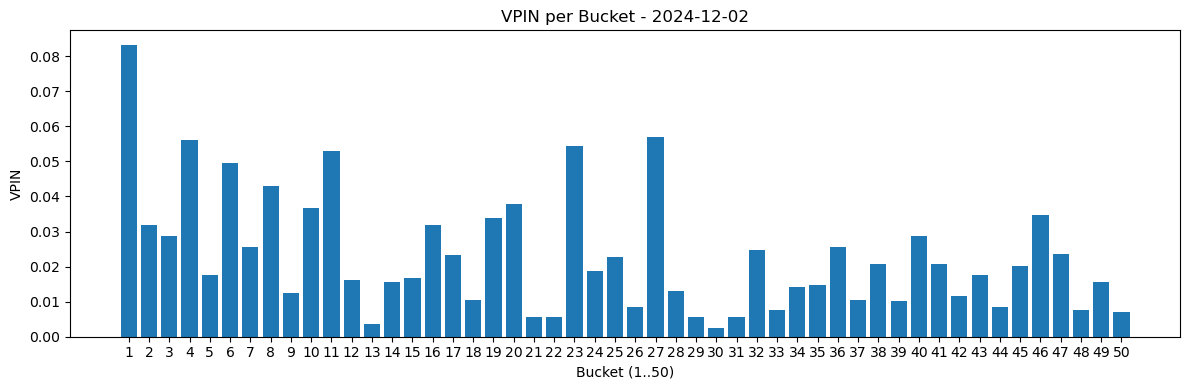

Saved vpin_first_day.png


In [10]:
# Calculate bucket size V_d = daily total volume / 50 for each day
daily_volume['V_d'] = daily_volume['DailyTotalVolume'] / 50
print(f'Computed V_d for {len(daily_volume)} days')
print(daily_volume.head())

# Use tick volume = BuyVolume + SellVolume (tick volume = 1 assumption)
nqc['Volume'] = nqc['BuyVolume'] + nqc['SellVolume']
print(f'Total tick volume (sum): {nqc['Volume'].sum()}')

# Propagate per-day totals into tick-level frame using transform (no separate merge needed)
nqc['DailyTotalVolume'] = nqc.groupby('Date')['Volume'].transform('sum')
nqc['V_d'] = nqc['DailyTotalVolume'] / 50
nqc['V_d'] = nqc['V_d'].replace(0, 1)
print('Added per-row DailyTotalVolume and V_d')

# Cumulative volume per day to assign buckets (counts ticks until V_d is filled)
nqc['cum_vol'] = nqc.groupby('Date')['Volume'].cumsum()
print('Computed cumulative volume (cum_vol) sample:')
print(nqc[['Date','cum_vol']].head())

# Compute bucket number 1..50. Use floor-style indexing so first V_d volumes -> bucket 1
nqc['bucket_number'] = ((nqc['cum_vol'] - 1) // nqc['V_d']).astype(int) + 1
nqc['bucket_number'] = nqc['bucket_number'].clip(lower=1, upper=50).astype(int)
print('Assigned bucket_number (1..50). Sample:')
print(nqc[['Date','cum_vol','V_d','bucket_number']].head())
print('Bucket counts per day:')
print(nqc.groupby('Date')['bucket_number'].nunique())

# Per-bucket totals (kept as columns on nqc so every tick knows its bucket's OI/V)
nqc['bucket_buy_sum'] = nqc.groupby(['Date','bucket_number'])['BuyVolume'].transform('sum')
nqc['bucket_sell_sum'] = nqc.groupby(['Date','bucket_number'])['SellVolume'].transform('sum')
nqc['bucket_V'] = nqc.groupby(['Date','bucket_number'])['Volume'].transform('sum')
nqc['bucket_OI'] = nqc['bucket_buy_sum'] - nqc['bucket_sell_sum']
# also store absolute OI for VPIN calculations
nqc['bucket_OI_abs'] = nqc['bucket_OI'].abs()

# VPIN per bucket (absolute OI divided by per-day V_d)
nqc['VPIN_bucket'] = nqc['bucket_OI_abs'] / nqc['V_d']
print('Computed per-bucket sums (buy/sell/V/OI) via transform')

print('Computed VPIN_bucket for each tick (same value for all ticks in bucket)')

# Mark the last tick of each bucket for quick checks (bucket filled at this tick)
nqc['pos_in_bucket'] = nqc.groupby(['Date','bucket_number']).cumcount()
nqc['bucket_size_ticks'] = nqc.groupby(['Date','bucket_number'])['Volume'].transform('size')
nqc['is_bucket_end'] = nqc['pos_in_bucket'] == (nqc['bucket_size_ticks'] - 1)
print('Marked bucket end rows; sample of bucket-end rows:')
print(nqc[nqc['is_bucket_end']].head()[['Date','bucket_number','bucket_V','bucket_OI_abs','VPIN_bucket']])

# Optionally create a compact bucket summary (one row per day+bucket)
buckets = nqc[nqc['is_bucket_end']].copy()[['Date','bucket_number','bucket_buy_sum','bucket_sell_sum','bucket_V','bucket_OI_abs','V_d','VPIN_bucket']]
buckets = buckets.rename(columns={'bucket_number':'bucket_idx','bucket_buy_sum':'buy','bucket_sell_sum':'sell','bucket_V':'V','bucket_OI_abs':'OI'})
buckets = buckets.sort_values(['Date','bucket_idx']).reset_index(drop=True)

out_buckets = 'buckets_50_per_day.csv'
buckets.to_csv(out_buckets, index=False)
print(f'✓ Saved bucket summary: {out_buckets} — shape: {buckets.shape}')

# Plotting: VPIN for first day (bar plot of 50 buckets) and optional 5x10 grid
import matplotlib.pyplot as plt
def plot_first_day_vpin(buckets_df, show_grid50=False):
    if buckets_df.empty:
        print('No bucket data available to plot')
        return
    first_day = buckets_df['Date'].iloc[0]
    day_df = buckets_df[buckets_df['Date'] == first_day].sort_values('bucket_idx')
    if day_df.empty:
        print('No buckets for first day found')
        return
    # Bar plot of VPIN per bucket
    fig, ax = plt.subplots(figsize=(12,4))
    ax.bar(day_df['bucket_idx'], day_df['VPIN_bucket'])
    ax.set_xlabel('Bucket (1..50)')
    ax.set_ylabel('VPIN')
    ax.set_title(f'VPIN per Bucket - {first_day}')
    ax.set_xticks(range(1,51))
    plt.tight_layout()
    plt.show()
    fig.savefig('vpin_first_day.png')
    print('Saved vpin_first_day.png')
    if show_grid50:
        # grid of 50 small subplots (5 rows x 10 cols)
        fig2, axes = plt.subplots(5,10, figsize=(15,8), sharey=True)
        axes = axes.flatten()
        for i, ax2 in enumerate(axes, start=1):
            row = day_df[day_df['bucket_idx']==i]
            val = row['VPIN_bucket'].iloc[0] if not row.empty else 0
            ax2.bar([0], [val])
            ax2.set_title(f'b{i}')
            ax2.set_xticks([])
        plt.suptitle(f'VPIN small plots - {first_day}')
        plt.tight_layout()
        plt.show()
        fig2.savefig('vpin_first_day_grid50.png')
        print('Saved vpin_first_day_grid50.png')

# Call the plot function for the first day (bar plot only). Set show_grid50=True to get the 5x10 grid.
plot_first_day_vpin(buckets, show_grid50=False)

# --- Evolution plot: OI, VPIN, cumulative VPIN, Midprice for first day ---
def plot_evolution_day(buckets_df, nqc_df, day=None):
    import matplotlib.pyplot as plt
    import numpy as np
    if buckets_df.empty or nqc_df.empty:
        print('Missing data for evolution plot')
        return
    if day is None:
        day = buckets_df['Date'].iloc[0]
    day_b = buckets_df[buckets_df['Date'] == day].sort_values('bucket_idx')
    if day_b.empty:
        print('No bucket data for requested day:', day)
        return
    # Ensure VPIN column name (some versions use 'VPIN_bucket')
    vpcol = 'VPIN_bucket' if 'VPIN_bucket' in day_b.columns else ('VPIN' if 'VPIN' in day_b.columns else None)
    if vpcol is None:
        day_b['VPIN_bucket'] = day_b['OI'].abs() / day_b['V_d']
        vpcol = 'VPIN_bucket'
    # cumulative VPIN (sum of abs VPIN)
    day_b = day_b.copy()
    day_b['cum_VPIN'] = day_b[vpcol].abs().cumsum()
    # get midprice at bucket end from nqc (last tick in each bucket)
    mid_series = nqc_df[nqc_df['is_bucket_end'] & (nqc_df['Date'] == day)][['bucket_number','Mid']].drop_duplicates('bucket_number').set_index('bucket_number')['Mid']
    # align mid values to buckets
    day_b['Mid'] = day_b['bucket_idx'].map(mid_series).ffill().bfill()

# Call evolution plot for first day
plot_evolution_day(buckets, nqc, day=None)

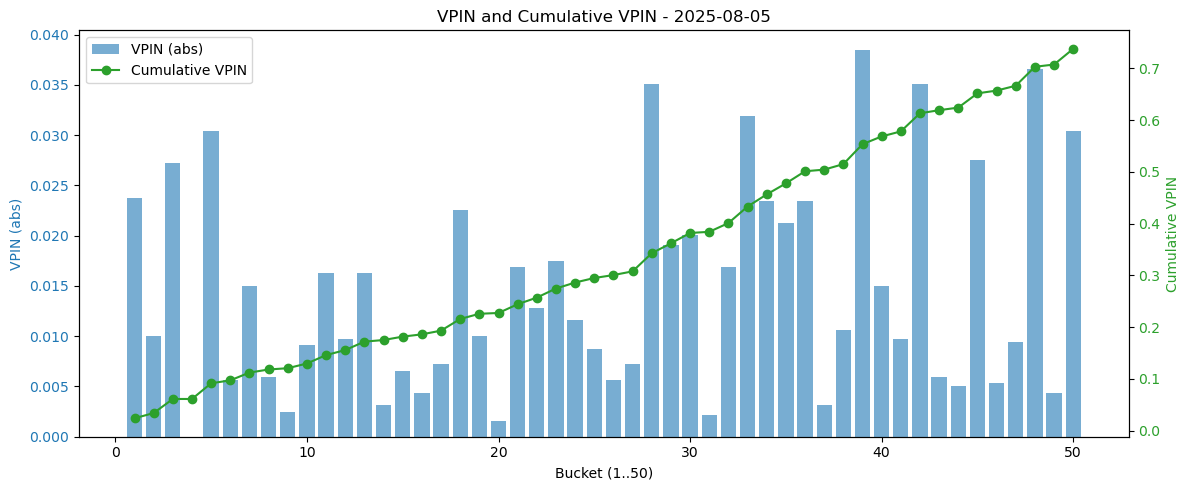

Saved vpin_and_cumvpin_first_day.png


In [12]:
# Plot VPIN (abs) and cumulative VPIN on the same figure for the first day
preferred_day = '2025-08-05'
day = preferred_day if (not buckets.empty and preferred_day in buckets['Date'].values) else (buckets['Date'].iloc[0] if not buckets.empty else None)

if day is None:
    print('No day available to plot')
else:
    day_b = buckets[buckets['Date'] == day].sort_values('bucket_idx').copy()
    vpcol = 'VPIN_bucket' if 'VPIN_bucket' in day_b.columns else ('VPIN' if 'VPIN' in day_b.columns else None)
    if vpcol is None:
        day_b['VPIN_bucket'] = day_b['OI'].abs() / day_b['V_d']
        vpcol = 'VPIN_bucket'
    day_b['cum_VPIN'] = day_b[vpcol].abs().cumsum()

    fig, ax1 = plt.subplots(figsize=(12,5))
    ax1.bar(day_b['bucket_idx'], day_b[vpcol].abs(), color='tab:blue', alpha=0.6, label='VPIN (abs)')
    ax1.set_xlabel('Bucket (1..50)')
    ax1.set_ylabel('VPIN (abs)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(day_b['bucket_idx'], day_b['cum_VPIN'], color='tab:green', marker='o', label='Cumulative VPIN')
    ax2.set_ylabel('Cumulative VPIN', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

    plt.title(f'VPIN and Cumulative VPIN - {day}')
    plt.tight_layout()
    plt.show()
    fig.savefig('vpin_and_cumvpin_first_day.png')
    print('Saved vpin_and_cumvpin_first_day.png')

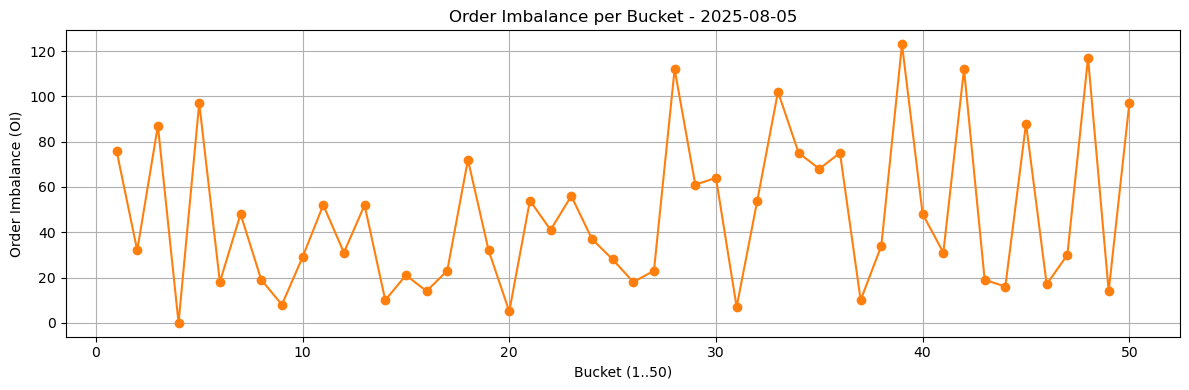

Saved OI_first_day.png


In [13]:
# Plot Order Imbalance (OI) per bucket in a separate cell
preferred_day = '2025-08-05'
day = preferred_day if (not buckets.empty and preferred_day in buckets['Date'].values) else (buckets['Date'].iloc[0] if not buckets.empty else None)
if day is None:
	print('No day available to plot OI')
else:
	day_b = buckets[buckets['Date'] == day].sort_values('bucket_idx').copy()
	fig, ax = plt.subplots(figsize=(12,4))
	ax.plot(day_b['bucket_idx'], day_b['OI'], color='tab:orange', marker='o')
	ax.set_xlabel('Bucket (1..50)')
	ax.set_ylabel('Order Imbalance (OI)')
	ax.set_title(f'Order Imbalance per Bucket - {day}')
	ax.grid(True)
	plt.tight_layout()
	plt.show()
	fig.savefig('OI_first_day.png')
	print('Saved OI_first_day.png')

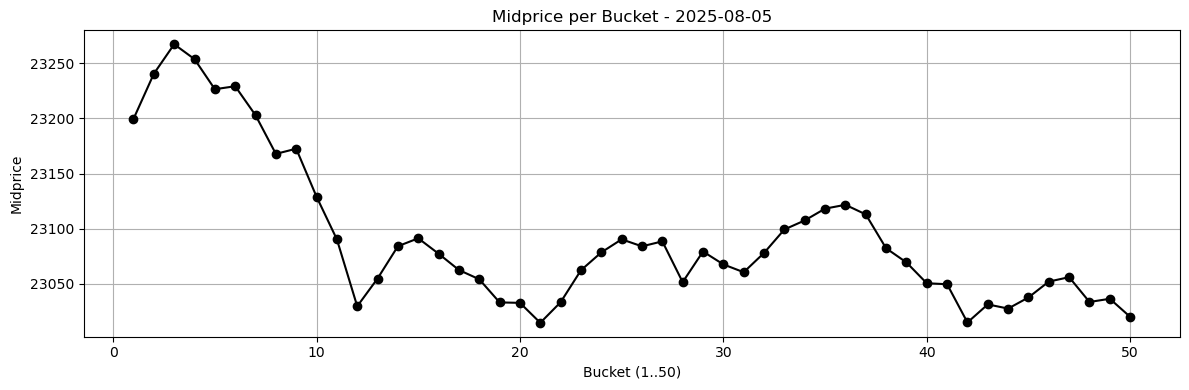

Saved midprice_first_day.png


In [14]:
# Plot Midprice per bucket in a separate cell
import matplotlib.pyplot as plt
preferred_day = '2025-08-05'
day = preferred_day if (not buckets.empty and preferred_day in buckets['Date'].values) else (buckets['Date'].iloc[0] if not buckets.empty else None)
if day is None:
	print('No day available to plot midprice')
else:
	day_b = buckets[buckets['Date'] == day].sort_values('bucket_idx').copy()
	# Extract midprice at bucket end from nqc (last tick in each bucket)
	mid_series = nqc[nqc['is_bucket_end'] & (nqc['Date'] == day)][['bucket_number','Mid']].drop_duplicates('bucket_number').set_index('bucket_number')['Mid']
	# map midprice (may forward/backfill if missing)
	day_b['Mid'] = day_b['bucket_idx'].map(mid_series).ffill().bfill()
	fig, ax = plt.subplots(figsize=(12,4))
	ax.plot(day_b['bucket_idx'], day_b['Mid'], color='black', marker='o')
	ax.set_xlabel('Bucket (1..50)')
	ax.set_ylabel('Midprice')
	ax.set_title(f'Midprice per Bucket - {day}')
	ax.grid(True)
	plt.tight_layout()
	plt.show()
	fig.savefig('midprice_first_day.png')
	print('Saved midprice_first_day.png')

In [15]:
# Show data for the checked day: bucket summary and tick-level sample (prefer 2025-08-05)
from IPython.display import display
preferred_day = '2025-08-05'
first_day = preferred_day if (not buckets.empty and preferred_day in buckets['Date'].values) else (buckets['Date'].iloc[0] if not buckets.empty else None)
print('Checked day:', first_day)
print('\nBucket summary (50 buckets):')
display(buckets[buckets['Date'] == first_day].reset_index(drop=True))
print('\nBucket summary shape:', buckets[buckets['Date'] == first_day].shape)
print('\nTick-level sample for checked day (first 200 rows):')
cols = ['Date','Time','Mid','Direction','BuyVolume','SellVolume','Volume','cum_vol','bucket_number','bucket_OI_abs','VPIN_bucket','is_bucket_end']
df_day = nqc[nqc['Date'] == first_day]
print('Tick-level rows for day:', len(df_day))
display(df_day[cols].head(200).reset_index(drop=True))

Checked day: 2025-08-05

Bucket summary (50 buckets):


,Date,bucket_idx,buy,sell,V,OI,V_d,VPIN_bucket
0,2025-08-05,1,1560.0,1636.0,3196.0,76.0,3195.58,0.023783
1,2025-08-05,2,1614.0,1582.0,3196.0,32.0,3195.58,0.010014
2,2025-08-05,3,1641.0,1554.0,3195.0,87.0,3195.58,0.027225
3,2025-08-05,4,1598.0,1598.0,3196.0,0.0,3195.58,0.000000
4,2025-08-05,5,1646.0,1549.0,3195.0,97.0,3195.58,0.030354
5,2025-08-05,6,1607.0,1589.0,3196.0,18.0,3195.58,0.005633
6,2025-08-05,7,1574.0,1622.0,3196.0,48.0,3195.58,0.015021
7,2025-08-05,8,1588.0,1607.0,3195.0,19.0,3195.58,0.005946
8,2025-08-05,9,1594.0,1602.0,3196.0,8.0,3195.58,0.002503
9,2025-08-05,10,1583.0,1612.0,3195.0,29.0,3195.58,0.009075



Bucket summary shape: (50, 8)

Tick-level sample for checked day (first 200 rows):
Tick-level rows for day: 159779


,Date,Time,Mid,Direction,BuyVolume,SellVolume,Volume,cum_vol,bucket_number,bucket_OI_abs,VPIN_bucket,is_bucket_end
0,2025-08-05,16:30:00.012,23234.00,1.0,1.0,0.0,1.0,1.0,1,76.0,0.023783,False
1,2025-08-05,16:30:00.224,23232.45,-1.0,0.0,1.0,1.0,2.0,1,76.0,0.023783,False
2,2025-08-05,16:30:00.240,23232.55,1.0,1.0,0.0,1.0,3.0,1,76.0,0.023783,False
3,2025-08-05,16:30:00.403,23228.75,-1.0,0.0,1.0,1.0,4.0,1,76.0,0.023783,False
4,2025-08-05,16:30:00.430,23229.05,1.0,1.0,0.0,1.0,5.0,1,76.0,0.023783,False
...,...,...,...,...,...,...,...,...,...,...,...,...
195,2025-08-05,16:30:23.289,23219.95,-1.0,0.0,1.0,1.0,196.0,1,76.0,0.023783,False
196,2025-08-05,16:30:23.412,23220.05,1.0,1.0,0.0,1.0,197.0,1,76.0,0.023783,False
197,2025-08-05,16:30:23.430,23219.55,-1.0,0.0,1.0,1.0,198.0,1,76.0,0.023783,False
198,2025-08-05,16:30:23.609,23218.95,-1.0,0.0,1.0,1.0,199.0,1,76.0,0.023783,False


In [11]:
# Compute per-bucket metrics: average spread and absolute return
# For each bucket, extract opening price (first mid), closing price (last mid), and average spread

# Create per-bucket opening/closing prices and spreads
bucket_metrics = []

for (day, bucket_idx), bucket_ticks in nqc.groupby(['Date', 'bucket_number']):
    if bucket_ticks.empty:
        continue
    
    # Opening price = first tick's mid in bucket
    opening_price = bucket_ticks['Mid'].iloc[0]
    
    # Closing price = last tick's mid in bucket
    closing_price = bucket_ticks['Mid'].iloc[-1]
    
    # Absolute return: (close - open) / open * 100, take absolute value
    abs_return = abs((closing_price - opening_price) / opening_price * 100) if opening_price != 0 else 0.0
    
    # Average spread = mean of (Ask - Bid) for all ticks in bucket
    bucket_ticks['Spread'] = bucket_ticks['Ask'] - bucket_ticks['Bid']
    avg_spread = bucket_ticks['Spread'].mean()
    
    bucket_metrics.append({
        'Date': day,
        'bucket_idx': bucket_idx,
        'opening_price': opening_price,
        'closing_price': closing_price,
        'abs_return': abs_return,
        'avg_spread': avg_spread
    })

# Create dataframe from metrics
bucket_metrics_df = pd.DataFrame(bucket_metrics)

# Merge these metrics into the main buckets dataframe
buckets = buckets.merge(bucket_metrics_df[['Date', 'bucket_idx', 'opening_price', 'closing_price', 'abs_return', 'avg_spread']], 
                         on=['Date', 'bucket_idx'], 
                         how='left')

print(f'✓ Added per-bucket metrics: opening_price, closing_price, abs_return, avg_spread')
print(f'Total bucket-level data points: {len(buckets)} (trading_days × 50 buckets)')
print(f'\nBucket metrics sample (first 10 rows):')
display(buckets[['Date', 'bucket_idx', 'V', 'OI', 'VPIN_bucket', 'abs_return', 'avg_spread']].head(10))
print(f'\nStatistics of new metrics:')
print(f'abs_return - min: {buckets["abs_return"].min():.4f}, max: {buckets["abs_return"].max():.4f}, mean: {buckets["abs_return"].mean():.4f}')
print(f'avg_spread - min: {buckets["avg_spread"].min():.6f}, max: {buckets["avg_spread"].max():.6f}, mean: {buckets["avg_spread"].mean():.6f}')

# Save enriched buckets dataframe
out_buckets_enriched = 'buckets_with_metrics.csv'
buckets.to_csv(out_buckets_enriched, index=False)
print(f'✓ Saved enriched buckets: {out_buckets_enriched} — shape: {buckets.shape}')


✓ Added per-bucket metrics: opening_price, closing_price, abs_return, avg_spread
Total bucket-level data points: 12802 (trading_days × 50 buckets)

Bucket metrics sample (first 10 rows):


,Date,bucket_idx,V,OI,VPIN_bucket,abs_return,avg_spread
0,2024-12-02,1,1983.0,165.0,0.083215,0.405905,0.923248
1,2024-12-02,2,1983.0,63.0,0.031773,0.035566,0.800000
2,2024-12-02,3,1983.0,57.0,0.028747,0.050343,0.800000
3,2024-12-02,4,1983.0,111.0,0.055981,0.066400,0.800000
4,2024-12-02,5,1983.0,35.0,0.017652,0.021329,0.800000
5,2024-12-02,6,1982.0,98.0,0.049425,0.171281,0.800000
6,2024-12-02,7,1983.0,51.0,0.025721,0.010649,0.800000
7,2024-12-02,8,1983.0,85.0,0.042868,0.113599,0.800000
8,2024-12-02,9,1983.0,25.0,0.012608,0.116399,0.800000
9,2024-12-02,10,1983.0,73.0,0.036816,0.072799,0.800000



Statistics of new metrics:
abs_return - min: 0.0000, max: 4.7239, mean: 0.0964
avg_spread - min: 0.700000, max: 3.906663, mean: 0.933899
✓ Saved enriched buckets: buckets_with_metrics.csv — shape: (12802, 12)


Regression data points: 12802 (out of 12802 total buckets)

LINEAR REGRESSION: VPIN → Volatility (Absolute Return)
Slope (coefficient): -0.001938
Intercept: 0.096486
R-squared: 0.000024
Correlation coefficient (r): -0.004858
P-value: 5.83e-01
Standard Error: 0.003527
Regression equation: abs_return = 0.096486 + -0.001938 * VPIN
Statistical significance: NO (p >= 0.05)
Interpretation: A 1-unit increase in VPIN is associated with a -0.001938% change in absolute return.


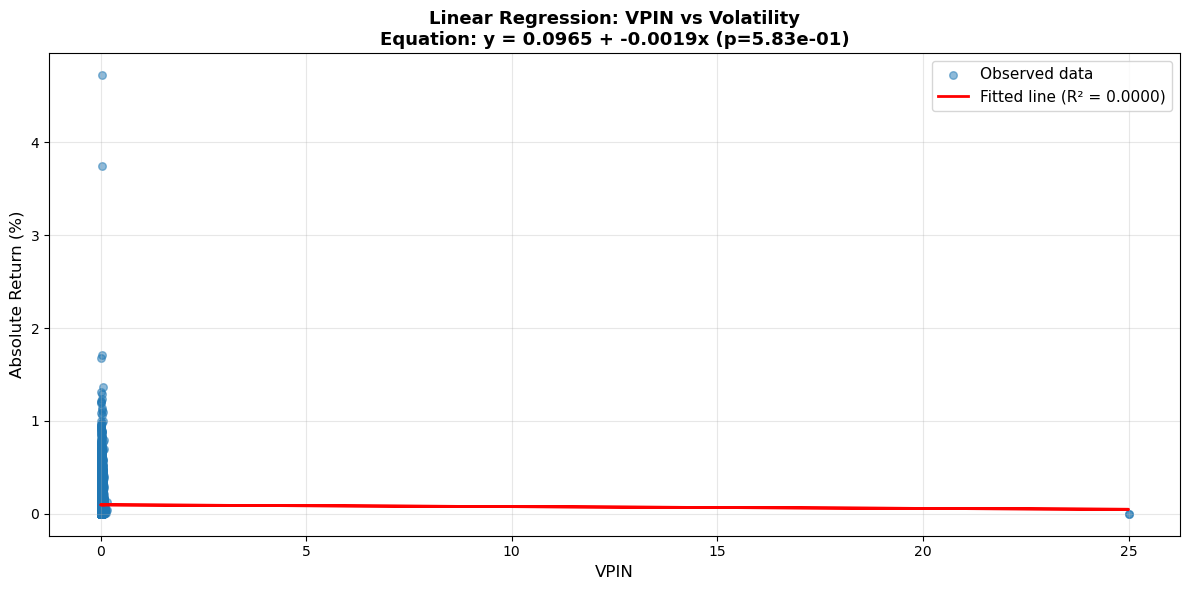


✓ Saved regression plot: vpin_regression_volatility.png

Additional Statistics:
Mean of VPIN: 0.020979
Std of VPIN: 0.312550
Mean of abs_return: 0.096446
Std of abs_return: 0.124714
Min/Max VPIN: 0.000000 / 25.000000
Min/Max abs_return: 0.000000 / 4.723891


In [17]:
# Linear Regression: VPIN predicts Volatility (absolute return)
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Prepare data: remove any NaN values
reg_data = buckets[['VPIN_bucket', 'abs_return']].dropna()
print(f'Regression data points: {len(reg_data)} (out of {len(buckets)} total buckets)')

# Extract variables
X = reg_data['VPIN_bucket'].values
y = reg_data['abs_return'].values

# Fit linear regression using scipy
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# Calculate R-squared
r_squared = r_value ** 2

# Generate predicted values
y_pred = intercept + slope * X

print('\n' + '='*60)
print('LINEAR REGRESSION: VPIN → Volatility (Absolute Return)')
print('='*60)
print(f'Slope (coefficient): {slope:.6f}')
print(f'Intercept: {intercept:.6f}')
print(f'R-squared: {r_squared:.6f}')
print(f'Correlation coefficient (r): {r_value:.6f}')
print(f'P-value: {p_value:.2e}')
print(f'Standard Error: {std_err:.6f}')
print(f'Regression equation: abs_return = {intercept:.6f} + {slope:.6f} * VPIN')
print('='*60)

# Interpretation
if p_value < 0.05:
    sig = 'YES (p < 0.05)'
else:
    sig = 'NO (p >= 0.05)'
print(f'Statistical significance: {sig}')
print(f'Interpretation: A 1-unit increase in VPIN is associated with a {slope:.6f}% change in absolute return.')

# Create scatter plot with regression line
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot
ax.scatter(X, y, alpha=0.5, s=30, label='Observed data')

# Regression line
ax.plot(X, y_pred, color='red', linewidth=2, label=f'Fitted line (R² = {r_squared:.4f})')

# Labels and title
ax.set_xlabel('VPIN', fontsize=12)
ax.set_ylabel('Absolute Return (%)', fontsize=12)
ax.set_title(f'Linear Regression: VPIN vs Volatility\nEquation: y = {intercept:.4f} + {slope:.4f}x (p={p_value:.2e})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the plot
fig.savefig('vpin_regression_volatility.png', dpi=300)
print(f'\n✓ Saved regression plot: vpin_regression_volatility.png')

# Additional statistics
print(f'\nAdditional Statistics:')
print(f'Mean of VPIN: {X.mean():.6f}')
print(f'Std of VPIN: {X.std():.6f}')
print(f'Mean of abs_return: {y.mean():.6f}')
print(f'Std of abs_return: {y.std():.6f}')
print(f'Min/Max VPIN: {X.min():.6f} / {X.max():.6f}')
print(f'Min/Max abs_return: {y.min():.6f} / {y.max():.6f}')


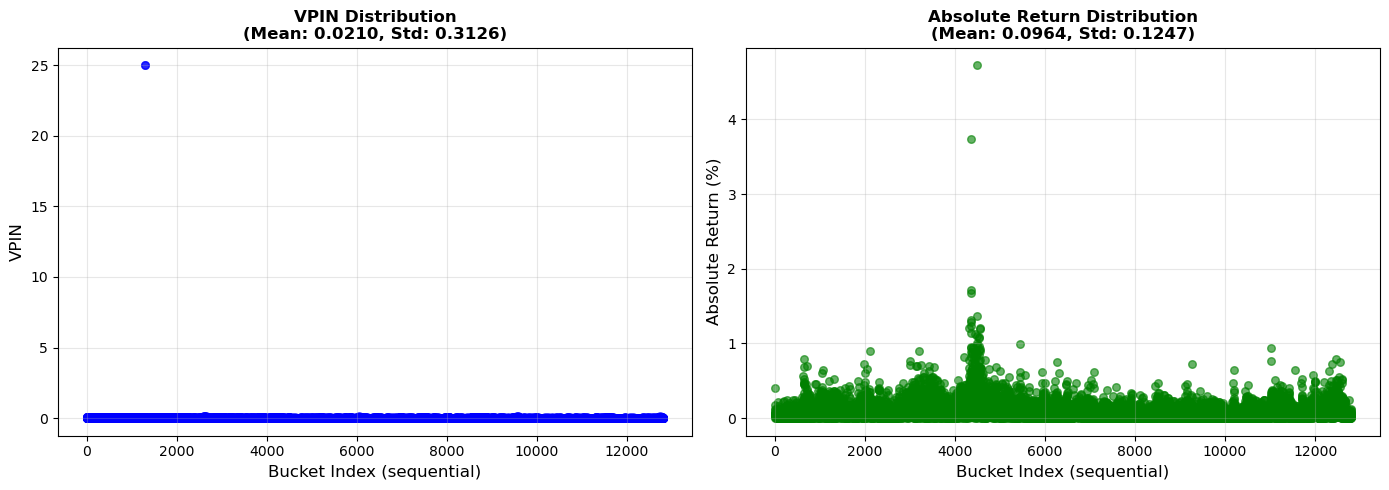

✓ Saved scatter plots: vpin_and_absreturn_distributions.png

VPIN STATISTICS
Count: 12802
Mean: 0.020979
Median: 0.013974
Std Dev: 0.312550
Min: 0.000000
Max: 25.000000
25th percentile: 0.006529
75th percentile: 0.024140

ABSOLUTE RETURN STATISTICS
Count: 12802
Mean: 0.096446
Median: 0.061170
Std Dev: 0.124714
Min: 0.000000
Max: 4.723891
25th percentile: 0.026639
75th percentile: 0.123621


In [18]:
# Scatter plots of VPIN and absolute return distributions
import matplotlib.pyplot as plt

# Prepare clean data
reg_data = buckets[['VPIN_bucket', 'abs_return']].dropna()
X = reg_data['VPIN_bucket'].values
y = reg_data['abs_return'].values

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot 1: VPIN values over bucket index
ax1.scatter(range(len(X)), X, alpha=0.6, s=30, color='blue')
ax1.set_xlabel('Bucket Index (sequential)', fontsize=12)
ax1.set_ylabel('VPIN', fontsize=12)
ax1.set_title(f'VPIN Distribution\n(Mean: {X.mean():.4f}, Std: {X.std():.4f})', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Scatter plot 2: Absolute return values over bucket index
ax2.scatter(range(len(y)), y, alpha=0.6, s=30, color='green')
ax2.set_xlabel('Bucket Index (sequential)', fontsize=12)
ax2.set_ylabel('Absolute Return (%)', fontsize=12)
ax2.set_title(f'Absolute Return Distribution\n(Mean: {y.mean():.4f}, Std: {y.std():.4f})', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

fig.savefig('vpin_and_absreturn_distributions.png', dpi=300)
print('✓ Saved scatter plots: vpin_and_absreturn_distributions.png')

# Print summary statistics
print('\n' + '='*60)
print('VPIN STATISTICS')
print('='*60)
print(f'Count: {len(X)}')
print(f'Mean: {X.mean():.6f}')
print(f'Median: {np.median(X):.6f}')
print(f'Std Dev: {X.std():.6f}')
print(f'Min: {X.min():.6f}')
print(f'Max: {X.max():.6f}')
print(f'25th percentile: {np.percentile(X, 25):.6f}')
print(f'75th percentile: {np.percentile(X, 75):.6f}')

print('\n' + '='*60)
print('ABSOLUTE RETURN STATISTICS')
print('='*60)
print(f'Count: {len(y)}')
print(f'Mean: {y.mean():.6f}')
print(f'Median: {np.median(y):.6f}')
print(f'Std Dev: {y.std():.6f}')
print(f'Min: {y.min():.6f}')
print(f'Max: {y.max():.6f}')
print(f'25th percentile: {np.percentile(y, 25):.6f}')
print(f'75th percentile: {np.percentile(y, 75):.6f}')


Original data points: 12802
VPIN outliers (> 3 std): 2
Abs_return outliers (> 3 std): 193
Total outliers removed: 195
Clean data points: 12607

LINEAR REGRESSION (OUTLIERS REMOVED): VPIN → Volatility
Slope (coefficient): 0.625879
Intercept: 0.076433
R-squared: 0.010569
Correlation coefficient (r): 0.102807
P-value: 5.66e-31
Standard Error: 0.053938
Regression equation: abs_return = 0.076433 + 0.625879 * VPIN
Statistical significance: YES (p < 0.05) - SIGNIFICANT
Interpretation: A 1-unit increase in VPIN is associated with a 0.625879% change in absolute return.


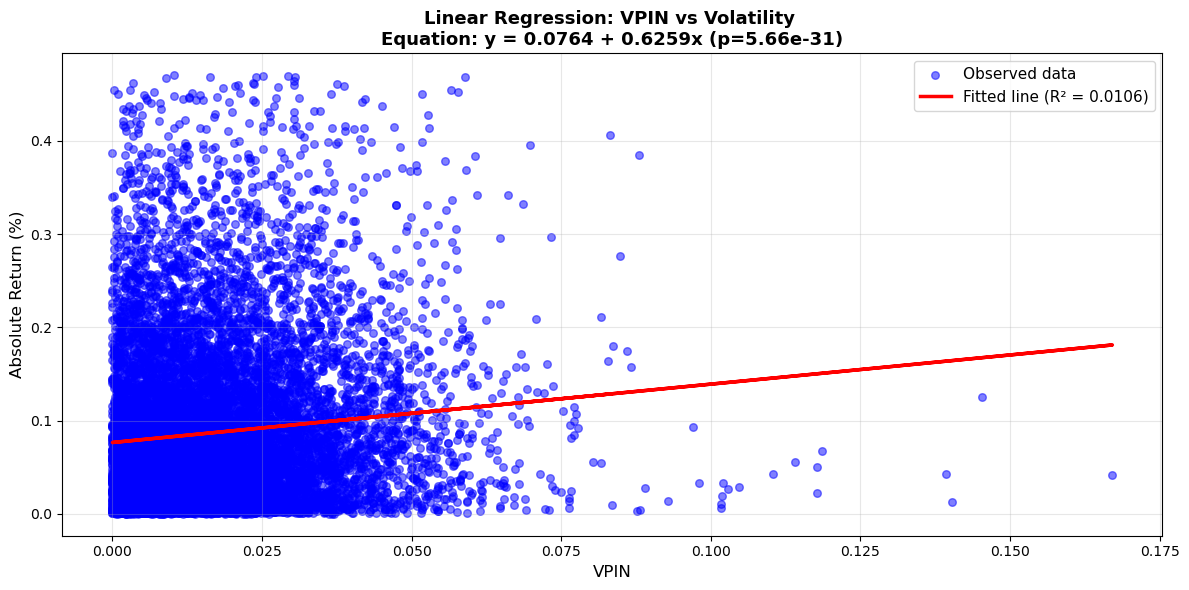


✓ Saved regression plot: vpin_regression_volatility_no_outliers.png

Clean Data Statistics:
Mean of VPIN: 0.016984
Std of VPIN: 0.013905
Mean of abs_return: 0.087063
Std of abs_return: 0.084653
Min/Max VPIN: 0.000000 / 0.167103
Min/Max abs_return: 0.000000 / 0.470430


In [19]:
# Remove extremes (> 3 std from mean) and rerun regression
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Prepare data: remove any NaN values
reg_data = buckets[['VPIN_bucket', 'abs_return']].dropna().copy()
print(f'Original data points: {len(reg_data)}')

# Calculate mean and std for both variables
vpin_mean = reg_data['VPIN_bucket'].mean()
vpin_std = reg_data['VPIN_bucket'].std()
absret_mean = reg_data['abs_return'].mean()
absret_std = reg_data['abs_return'].std()

# Define threshold: 3 standard deviations
threshold = 3

# Identify outliers
vpin_outliers = (reg_data['VPIN_bucket'] - vpin_mean).abs() > threshold * vpin_std
absret_outliers = (reg_data['abs_return'] - absret_mean).abs() > threshold * absret_std

outlier_mask = vpin_outliers | absret_outliers
n_outliers = outlier_mask.sum()

print(f'VPIN outliers (> 3 std): {vpin_outliers.sum()}')
print(f'Abs_return outliers (> 3 std): {absret_outliers.sum()}')
print(f'Total outliers removed: {n_outliers}')

# Remove outliers
reg_data_clean = reg_data[~outlier_mask].copy()
print(f'Clean data points: {len(reg_data_clean)}')

# Extract variables
X = reg_data_clean['VPIN_bucket'].values
y = reg_data_clean['abs_return'].values

# Fit linear regression using scipy
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# Calculate R-squared
r_squared = r_value ** 2

# Generate predicted values
y_pred = intercept + slope * X

print('\n' + '='*60)
print('LINEAR REGRESSION (OUTLIERS REMOVED): VPIN → Volatility')
print('='*60)
print(f'Slope (coefficient): {slope:.6f}')
print(f'Intercept: {intercept:.6f}')
print(f'R-squared: {r_squared:.6f}')
print(f'Correlation coefficient (r): {r_value:.6f}')
print(f'P-value: {p_value:.2e}')
print(f'Standard Error: {std_err:.6f}')
print(f'Regression equation: abs_return = {intercept:.6f} + {slope:.6f} * VPIN')
print('='*60)

# Interpretation
if p_value < 0.05:
    sig = 'YES (p < 0.05) - SIGNIFICANT'
else:
    sig = 'NO (p >= 0.05) - NOT SIGNIFICANT'
print(f'Statistical significance: {sig}')
print(f'Interpretation: A 1-unit increase in VPIN is associated with a {slope:.6f}% change in absolute return.')

# Create scatter plot with regression line (clean data)
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot
ax.scatter(X, y, alpha=0.5, s=30, label='Observed data', color='blue')

# Regression line
ax.plot(X, y_pred, color='red', linewidth=2.5, label=f'Fitted line (R² = {r_squared:.4f})')

# Labels and title
ax.set_xlabel('VPIN', fontsize=12)
ax.set_ylabel('Absolute Return (%)', fontsize=12)
ax.set_title(f'Linear Regression: VPIN vs Volatility \nEquation: y = {intercept:.4f} + {slope:.4f}x (p={p_value:.2e})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the plot
fig.savefig('vpin_regression_volatility_no_outliers.png', dpi=300)
print(f'\n✓ Saved regression plot: vpin_regression_volatility_no_outliers.png')

# Additional statistics (clean data)
print(f'\nClean Data Statistics:')
print(f'Mean of VPIN: {X.mean():.6f}')
print(f'Std of VPIN: {X.std():.6f}')
print(f'Mean of abs_return: {y.mean():.6f}')
print(f'Std of abs_return: {y.std():.6f}')
print(f'Min/Max VPIN: {X.min():.6f} / {X.max():.6f}')
print(f'Min/Max abs_return: {y.min():.6f} / {y.max():.6f}')


Removing 1 outliers (> 3 std) from scatter data


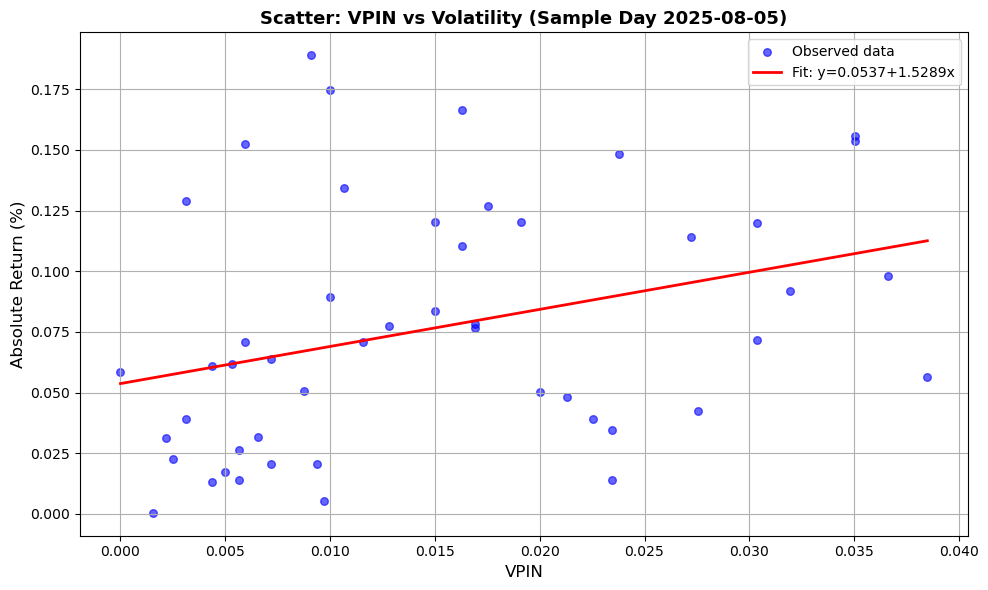

Saved vpin_vs_volatility_scatter.png


In [20]:
# Scatter plot: VPIN vs Absolute Return (Volatility) — remove >3 std outliers
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for 2025-08-05 and remove extremes (> 3 std) similarly to previous cell
reg_data = buckets[buckets['Date'] == '2025-08-05'][['VPIN_bucket','abs_return']].dropna().copy()
# compute means and stds
vpin_mean = reg_data['VPIN_bucket'].mean()
vpin_std = reg_data['VPIN_bucket'].std()
absret_mean = reg_data['abs_return'].mean()
absret_std = reg_data['abs_return'].std()
threshold = 3
vpin_outliers = (reg_data['VPIN_bucket'] - vpin_mean).abs() > threshold * vpin_std
absret_outliers = (reg_data['abs_return'] - absret_mean).abs() > threshold * absret_std
outlier_mask = vpin_outliers | absret_outliers
n_outliers = outlier_mask.sum()
print(f'Removing {n_outliers} outliers (> {threshold} std) from scatter data')
reg_data_clean = reg_data[~outlier_mask].copy()
X = reg_data_clean['VPIN_bucket'].values
y = reg_data_clean['abs_return'].values

# Scatter and regression line using same colours as previous graph (blue points, red fit)
fig, ax = plt.subplots(figsize=(10,6))
ax.scatter(X, y, alpha=0.6, s=30, color='blue', label='Observed data')
# fit linear regression for display if enough points
if len(X) > 1:
    m, b = np.polyfit(X, y, 1)
    xs = np.linspace(X.min(), X.max(), 100)
    ax.plot(xs, m*xs + b, color='red', linewidth=2, label=f'Fit: y={b:.4f}+{m:.4f}x')

ax.set_xlabel('VPIN', fontsize=12)
ax.set_ylabel('Absolute Return (%)', fontsize=12)
ax.set_title('Scatter: VPIN vs Volatility (Sample Day 2025-08-05)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
print('Saved vpin_vs_volatility_scatter.png')

Original end

GC_IC_Updated

In [28]:
# Load GC data
import pandas as pd

gc = pd.read_csv('GC_IC_Updated.csv', sep='\t')
print(type(gc))
print(gc.shape)
print(gc.head())


<class 'pandas.core.frame.DataFrame'>
(17242804, 7)
       <DATE>        <TIME>    <BID>    <ASK>  <LAST>  <VOLUME>  <FLAGS>
0  2025.05.01  01:00:02.033  3289.25  3289.42     NaN       NaN        6
1  2025.05.01  01:00:02.205  3289.16  3289.33     NaN       NaN        6
2  2025.05.01  01:00:02.411  3289.21  3289.38     NaN       NaN        6
3  2025.05.01  01:00:02.606  3289.26  3289.43     NaN       NaN        6
4  2025.05.01  01:00:02.801  3289.22  3289.39     NaN       NaN        6


In [29]:
# Clean GC data: forward-fill Bid/Ask, drop unwanted cols, round and save final CSV
# Filter to: dates >= 2024-12-01 AND US trading hours (mapped to America/New_York 09:30-16:00)
cols_needed = ['<DATE>', '<TIME>', '<BID>', '<ASK>']
for c in ['DATE','TIME','BID','ASK']:
    if c in gc.columns and ('<' + c + '>') not in gc.columns:
        cols_needed = ['DATE','TIME','BID','ASK']
        break

# Ensure Bid/Ask numeric
for col in ['<BID>','<ASK>','BID','ASK']:
    if col in gc.columns:
        gc[col] = pd.to_numeric(gc[col], errors='coerce')

# Identify which date/time columns to use
date_col = 'DATE' if 'DATE' in gc.columns else ('<DATE>' if '<DATE>' in gc.columns else None)
time_col = 'TIME' if 'TIME' in gc.columns else ('<TIME>' if '<TIME>' in gc.columns else None)

initial_rows = len(gc)
print(f'Initial rows: {initial_rows}')

if date_col:
    gc[date_col] = pd.to_datetime(gc[date_col], errors='coerce')
    before_date_rows = len(gc)
    gc = gc[gc[date_col] >= pd.Timestamp('2024-12-01')]
    after_date_rows = len(gc)
    print(f'Rows before date filter: {before_date_rows} -> after date filter: {after_date_rows}')
else:
    print('Warning: no date column found; skipping date filter')

if time_col and date_col:
    gc[time_col] = gc[time_col].astype(str).str.strip()
    combined = pd.to_datetime(gc[date_col].dt.strftime('%Y-%m-%d') + ' ' + gc[time_col], errors='coerce')
    
    dataset_tz = 'Europe/Bucharest'
    target_tz = 'America/New_York'
    
    combined = combined.dt.tz_localize(dataset_tz, ambiguous='NaT', nonexistent='shift_forward')
    combined_ny = combined.dt.tz_convert(target_tz)
    
    from datetime import time as dtime
    times_ny = combined_ny.dt.time
    mask_time = times_ny >= dtime(9, 30)
    mask_time &= times_ny <= dtime(16, 0)
    
    before_time_rows = len(gc)
    gc = gc[mask_time.fillna(False).values]
    after_time_rows = len(gc)
    print(f'Rows before time filter: {before_time_rows} -> after time filter: {after_time_rows} (NY hours 09:30-16:00)')
    
    del combined, combined_ny, times_ny, mask_time
else:
    print('Warning: missing date or time column; skipping time-of-day filter')

gc = gc.fillna(method='ffill')

prefer_cols = []
if 'DATE' in gc.columns and 'TIME' in gc.columns:
    prefer_cols = ['DATE','TIME']
elif '<DATE>' in gc.columns and '<TIME>' in gc.columns:
    prefer_cols = ['<DATE>','<TIME>']

bid_col = 'BID' if 'BID' in gc.columns else ('<BID>' if '<BID>' in gc.columns else None)
ask_col = 'ASK' if 'ASK' in gc.columns else ('<ASK>' if '<ASK>' in gc.columns else None)

final_cols = []
if prefer_cols:
    final_cols.extend(prefer_cols)
if bid_col:
    final_cols.append(bid_col)
if ask_col:
    final_cols.append(ask_col)

if len(final_cols) < 2:
    raise ValueError(f'Not enough columns to select Date and Time. final_cols={final_cols}')

gc_clean_df = gc[final_cols].copy()
rename_map = {}
if len(final_cols) >= 1 and final_cols[0] in ['<DATE>','DATE']:
    rename_map[final_cols[0]] = 'Date'
if len(final_cols) >= 2 and final_cols[1] in ['<TIME>','TIME']:
    rename_map[final_cols[1]] = 'Time'
if bid_col:
    rename_map[bid_col] = 'Bid'
if ask_col:
    rename_map[ask_col] = 'Ask'
gc_clean_df = gc_clean_df.rename(columns=rename_map)

if 'Bid' in gc_clean_df.columns:
    gc_clean_df['Bid'] = gc_clean_df['Bid'].round(3)
if 'Ask' in gc_clean_df.columns:
    gc_clean_df['Ask'] = gc_clean_df['Ask'].round(3)

gc_clean_df = gc_clean_df.dropna(subset=['Bid','Ask'], how='all')

out_final_gc = 'icm_gc_final_cleaned.csv'
gc_clean_df.to_csv(out_final_gc, index=False)
print(f'✓ Saved final cleaned CSV: {out_final_gc} — shape: {gc_clean_df.shape}')


Initial rows: 17242804
Rows before date filter: 17242804 -> after date filter: 17242804
Rows before time filter: 17242804 -> after time filter: 5898894 (NY hours 09:30-16:00)


C:\Users\lucca\AppData\Local\Temp\ipykernel_7356\1073035152.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  gc = gc.fillna(method='ffill')


✓ Saved final cleaned CSV: icm_gc_final_cleaned.csv — shape: (5898894, 4)


In [12]:
# Load cleaned GC CSV and create midprice
gcc = pd.read_csv('icm_gc_final_cleaned.csv')
print(type(gcc))
print(gcc.shape)
#print(gcc.head())

gcc['Mid'] = (gcc['Bid'] + gcc['Ask']) / 2
#print(gcc.head())


<class 'pandas.core.frame.DataFrame'>
(5898894, 4)


In [13]:
# Classify volume for GC: buy when midprice increases, sell when decreases
import numpy as np

gcc['PrevMidPrice'] = gcc['Mid'].shift(1)

gcc['Direction'] = 0.0
gcc.loc[gcc['Mid'] > gcc['PrevMidPrice'], 'Direction'] = 1  # Buy
gcc.loc[gcc['Mid'] < gcc['PrevMidPrice'], 'Direction'] = -1  # Sell

gcc['Direction'] = gcc['Direction'].replace(0, np.nan).ffill().bfill()

gcc['BuyVolume'] = (gcc['Direction'] == 1).astype(float)
gcc['SellVolume'] = (gcc['Direction'] == -1).astype(float)

print(gcc['Direction'].value_counts())
print('BuyVolume sum:', gcc['BuyVolume'].sum(), 'SellVolume sum:', gcc['SellVolume'].sum())
print(gcc.head())


Direction
 1.0    2989420
-1.0    2909474
Name: count, dtype: int64
BuyVolume sum: 2989420.0 SellVolume sum: 2909474.0
         Date          Time      Bid      Ask       Mid  PrevMidPrice  \
0  2025-05-02  16:30:00.034  3257.38  3257.48  3257.430           NaN   
1  2025-05-02  16:30:00.228  3257.15  3257.25  3257.200      3257.430   
2  2025-05-02  16:30:00.432  3256.60  3256.71  3256.655      3257.200   
3  2025-05-02  16:30:00.610  3257.14  3257.25  3257.195      3256.655   
4  2025-05-02  16:30:00.803  3257.24  3257.35  3257.295      3257.195   

   Direction  BuyVolume  SellVolume  
0       -1.0        0.0         1.0  
1       -1.0        0.0         1.0  
2       -1.0        0.0         1.0  
3        1.0        1.0         0.0  
4        1.0        1.0         0.0  


In [14]:
# Calculate buckets and VPIN for GC
import matplotlib.pyplot as plt

daily_volume_gc = gcc.groupby('Date')[['BuyVolume', 'SellVolume']].sum().reset_index()
daily_volume_gc['TotalVolume'] = daily_volume_gc['BuyVolume'] + daily_volume_gc['SellVolume']
daily_volume_gc.columns = ['Date', 'DailyBuyVolume', 'DailySellVolume', 'DailyTotalVolume']

daily_volume_gc['V_d'] = daily_volume_gc['DailyTotalVolume'] / 50
print(f'Computed V_d for {len(daily_volume_gc)} days')
print(daily_volume_gc.head())

gcc['Volume'] = gcc['BuyVolume'] + gcc['SellVolume']
gcc['DailyTotalVolume'] = gcc.groupby('Date')['Volume'].transform('sum')
gcc['V_d'] = gcc['DailyTotalVolume'] / 50
gcc['V_d'] = gcc['V_d'].replace(0, 1)

gcc['cum_vol'] = gcc.groupby('Date')['Volume'].cumsum()

gcc['bucket_number'] = ((gcc['cum_vol'] - 1) // gcc['V_d']).astype(int) + 1
gcc['bucket_number'] = gcc['bucket_number'].clip(lower=1, upper=50).astype(int)

gcc['bucket_buy_sum'] = gcc.groupby(['Date','bucket_number'])['BuyVolume'].transform('sum')
gcc['bucket_sell_sum'] = gcc.groupby(['Date','bucket_number'])['SellVolume'].transform('sum')
gcc['bucket_V'] = gcc.groupby(['Date','bucket_number'])['Volume'].transform('sum')
gcc['bucket_OI'] = gcc['bucket_buy_sum'] - gcc['bucket_sell_sum']
gcc['bucket_OI_abs'] = gcc['bucket_OI'].abs()

gcc['VPIN_bucket'] = gcc['bucket_OI_abs'] / gcc['V_d']

gcc['pos_in_bucket'] = gcc.groupby(['Date','bucket_number']).cumcount()
gcc['bucket_size_ticks'] = gcc.groupby(['Date','bucket_number'])['Volume'].transform('size')
gcc['is_bucket_end'] = gcc['pos_in_bucket'] == (gcc['bucket_size_ticks'] - 1)

# Create bucket summary for GC
gc_buckets = gcc[gcc['is_bucket_end']].copy()[['Date','bucket_number','bucket_buy_sum','bucket_sell_sum','bucket_V','bucket_OI_abs','V_d','VPIN_bucket']]
gc_buckets = gc_buckets.rename(columns={'bucket_number':'bucket_idx','bucket_buy_sum':'buy','bucket_sell_sum':'sell','bucket_V':'V','bucket_OI_abs':'OI'})
gc_buckets = gc_buckets.sort_values(['Date','bucket_idx']).reset_index(drop=True)

out_gc_buckets = 'gc_buckets_50_per_day.csv'
gc_buckets.to_csv(out_gc_buckets, index=False)
print(f'✓ Saved GC bucket summary: {out_gc_buckets} — shape: {gc_buckets.shape}')


Computed V_d for 84 days
         Date  DailyBuyVolume  DailySellVolume  DailyTotalVolume      V_d
0  2025-05-02         35343.0          30033.0           65376.0  1307.52
1  2025-05-05         30170.0          28572.0           58742.0  1174.84
2  2025-05-06         32765.0          30206.0           62971.0  1259.42
3  2025-08-08         38021.0          37768.0           75789.0  1515.78
4  2025-08-11         26734.0          26863.0           53597.0  1071.94
✓ Saved GC bucket summary: gc_buckets_50_per_day.csv — shape: (4200, 8)


In [15]:
# Compute per-bucket metrics for GC: average spread and absolute return
gc_bucket_metrics = []

for (day, bucket_idx), bucket_ticks in gcc.groupby(['Date', 'bucket_number']):
    if bucket_ticks.empty:
        continue
    
    opening_price = bucket_ticks['Mid'].iloc[0]
    closing_price = bucket_ticks['Mid'].iloc[-1]
    abs_return = abs((closing_price - opening_price) / opening_price * 100) if opening_price != 0 else 0.0
    
    bucket_ticks['Spread'] = bucket_ticks['Ask'] - bucket_ticks['Bid']
    avg_spread = bucket_ticks['Spread'].mean()
    
    gc_bucket_metrics.append({
        'Date': day,
        'bucket_idx': bucket_idx,
        'opening_price': opening_price,
        'closing_price': closing_price,
        'abs_return': abs_return,
        'avg_spread': avg_spread
    })

gc_bucket_metrics_df = pd.DataFrame(gc_bucket_metrics)

gc_buckets = gc_buckets.merge(gc_bucket_metrics_df[['Date', 'bucket_idx', 'opening_price', 'closing_price', 'abs_return', 'avg_spread']], 
                         on=['Date', 'bucket_idx'], 
                         how='left')

print(f'✓ Added GC per-bucket metrics: opening_price, closing_price, abs_return, avg_spread')
print(f'Total GC bucket-level data points: {len(gc_buckets)} (trading_days × 50 buckets)')
print(f'Statistics of GC metrics:')
print(f'abs_return - min: {gc_buckets["abs_return"].min():.4f}, max: {gc_buckets["abs_return"].max():.4f}, mean: {gc_buckets["abs_return"].mean():.4f}')
print(f'avg_spread - min: {gc_buckets["avg_spread"].min():.6f}, max: {gc_buckets["avg_spread"].max():.6f}, mean: {gc_buckets["avg_spread"].mean():.6f}')

out_gc_buckets_enriched = 'gc_buckets_with_metrics.csv'
gc_buckets.to_csv(out_gc_buckets_enriched, index=False)
print(f'✓ Saved enriched GC buckets: {out_gc_buckets_enriched} — shape: {gc_buckets.shape}')


✓ Added GC per-bucket metrics: opening_price, closing_price, abs_return, avg_spread
Total GC bucket-level data points: 4200 (trading_days × 50 buckets)
Statistics of GC metrics:
abs_return - min: 0.0000, max: 0.9284, mean: 0.0737
avg_spread - min: 0.049966, max: 0.474791, mean: 0.077003
✓ Saved enriched GC buckets: gc_buckets_with_metrics.csv — shape: (4200, 12)


In [34]:
# Filter GC data: remove outliers beyond 3 std from mean
cols_to_filter_gc = ['VPIN_bucket', 'abs_return', 'avg_spread', 'OI']
gc_buckets_clean = gc_buckets[cols_to_filter_gc].dropna().copy()

print(f'GC Original sample size: {len(gc_buckets_clean)}')
print('\nGC Outlier detection (3 std threshold):')

means_gc = gc_buckets_clean.mean()
stds_gc = gc_buckets_clean.std()

outlier_masks_gc = {}
for col in cols_to_filter_gc:
    outlier_masks_gc[col] = (gc_buckets_clean[col] - means_gc[col]).abs() > 3 * stds_gc[col]
    n_outliers = outlier_masks_gc[col].sum()
    print(f'{col}: {n_outliers} outliers')

combined_outlier_mask_gc = pd.concat(outlier_masks_gc, axis=1).any(axis=1)
n_total_outliers_gc = combined_outlier_mask_gc.sum()
print(f'\nTotal GC rows with outliers: {n_total_outliers_gc}')

gc_buckets_filtered = gc_buckets_clean[~combined_outlier_mask_gc].copy()
print(f'GC Clean sample size: {len(gc_buckets_filtered)} ({100*len(gc_buckets_filtered)/len(gc_buckets_clean):.1f}% retained)')

# Descriptive statistics for GC (3 std filtered)
cols = ['VPIN_bucket', 'abs_return', 'avg_spread', 'OI']
gc_desc_df = gc_buckets_filtered[cols].describe(percentiles=[0.25,0.5,0.75]).T
gc_desc_df = gc_desc_df.rename(columns={'50%':'median'})
gc_desc_df = gc_desc_df[['count','mean','std','min','25%','median','75%','max']].round(6)
print('\nGC Descriptive statistics (per-bucket, 3-std filtered)')
print(gc_desc_df.to_string())
gc_desc_df.to_csv('gc_descriptive_stats_buckets_filtered.csv')
print('Saved gc_descriptive_stats_buckets_filtered.csv')

# GC Correlation matrix (3 std filtered)
gc_corr_cols = ['VPIN_bucket','abs_return','avg_spread','OI']
gc_corr = gc_buckets_filtered[gc_corr_cols].corr().round(4)
print('\nGC Correlation matrix (3-std filtered):')
print(gc_corr.to_string())
gc_corr.to_csv('gc_correlation_matrix_buckets_filtered.csv')
print('Saved gc_correlation_matrix_buckets_filtered.csv')


GC Original sample size: 4200

GC Outlier detection (3 std threshold):
VPIN_bucket: 67 outliers
abs_return: 68 outliers
avg_spread: 35 outliers
OI: 80 outliers

Total GC rows with outliers: 203
GC Clean sample size: 3997 (95.2% retained)

GC Descriptive statistics (per-bucket, 3-std filtered)
              count       mean        std       min        25%     median        75%         max
VPIN_bucket  3997.0   0.048678   0.039738  0.000000   0.017670   0.038303   0.068686    0.192243
abs_return   3997.0   0.067693   0.059673  0.000000   0.022234   0.050367   0.096299    0.302382
avg_spread   3997.0   0.075995   0.015244  0.049966   0.067637   0.073474   0.084447    0.135372
OI           3997.0  68.157368  60.148461  0.000000  23.000000  50.000000  95.000000  291.000000
Saved gc_descriptive_stats_buckets_filtered.csv

GC Correlation matrix (3-std filtered):
             VPIN_bucket  abs_return  avg_spread      OI
VPIN_bucket       1.0000      0.0428     -0.0482  0.9254
abs_return        

In [17]:
# OLS Regression for GC (3-std filtered data)
import statsmodels.formula.api as smf

# Ensure gc_buckets_filtered exists (should come from cell 26)
if 'gc_buckets_filtered' not in globals():
    print("WARNING: gc_buckets_filtered not found. Running cell 26 logic...")
    # Fallback: recreate filtered data from gc_buckets if available
    if 'gc_buckets' in globals():
        cols_to_filter_gc = ['VPIN_bucket', 'abs_return', 'avg_spread', 'OI']
        gc_buckets_clean = gc_buckets[cols_to_filter_gc].dropna().copy()
        means_gc = gc_buckets_clean.mean()
        stds_gc = gc_buckets_clean.std()
        outlier_masks_gc = {col: (gc_buckets_clean[col] - means_gc[col]).abs() > 3 * stds_gc[col] for col in cols_to_filter_gc}
        combined_outlier_mask_gc = pd.concat(outlier_masks_gc, axis=1).any(axis=1)
        gc_buckets_filtered = gc_buckets[~combined_outlier_mask_gc.values].reset_index(drop=True)
    else:
        raise ValueError("gc_buckets not found either. Please run cells 24-26 first.")

gc_df_reg = gc_buckets_filtered[['VPIN_bucket','abs_return','avg_spread','OI']].dropna().copy()
print(f'GC Regression sample size (3-std filtered): {len(gc_df_reg)}')

# Model 1: abs_return ~ VPIN_bucket
gc_model1 = smf.ols('abs_return ~ VPIN_bucket', data=gc_df_reg).fit(cov_type='HC3')
print('\n' + '='*60)
print('GC OLS Model 1: abs_return ~ VPIN_bucket (HC3 SE, 3-std filtered)')
print('='*60)
print(gc_model1.summary())
with open('gc_ols_model1_summary_filtered.txt','w') as f:
    f.write(gc_model1.summary().as_text())
print('Saved gc_ols_model1_summary_filtered.txt')

# Model 2: abs_return ~ VPIN_bucket + avg_spread + OI
gc_model2 = smf.ols('abs_return ~ VPIN_bucket + avg_spread + OI', data=gc_df_reg).fit(cov_type='HC3')
print('\n' + '='*60)
print('GC OLS Model 2: abs_return ~ VPIN_bucket + avg_spread + OI (HC3 SE, 3-std filtered)')
print('='*60)
print(gc_model2.summary())
with open('gc_ols_model2_summary_filtered.txt','w') as f:
    f.write(gc_model2.summary().as_text())
print('Saved gc_ols_model2_summary_filtered.txt')

# GC Model 2 coefficients
gc_coefs = pd.DataFrame({
    'coef': gc_model2.params,
    'std_err': gc_model2.bse,
    't': gc_model2.tvalues,
    'pvalue': gc_model2.pvalues
})
gc_coefs = gc_coefs.round(6)
print('\nGC Model 2 coefficients (3-std filtered):')
print(gc_coefs.to_string())
gc_coefs.to_csv('gc_model2_coefficients_filtered.csv')
print('Saved gc_model2_coefficients_filtered.csv')

vp_coef_gc = gc_model2.params.get('VPIN_bucket', None)
vp_p_gc = gc_model2.pvalues.get('VPIN_bucket', None)
if vp_coef_gc is not None:
    print(f"\nGC VPIN coefficient = {vp_coef_gc:.6f} (p = {vp_p_gc:.4f})")
    if vp_p_gc < 0.05:
        print(' => Statistically significant at 5%: higher VPIN associated with higher abs return')
    else:
        print(' => Not statistically significant at 5%')


GC Regression sample size (3-std filtered): 3997

GC OLS Model 1: abs_return ~ VPIN_bucket (HC3 SE, 3-std filtered)
                            OLS Regression Results                            
Dep. Variable:             abs_return   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     7.676
Date:                Fri, 19 Dec 2025   Prob (F-statistic):            0.00562
Time:                        01:33:35   Log-Likelihood:                 5599.7
No. Observations:                3997   AIC:                        -1.120e+04
Df Residuals:                    3995   BIC:                        -1.118e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------

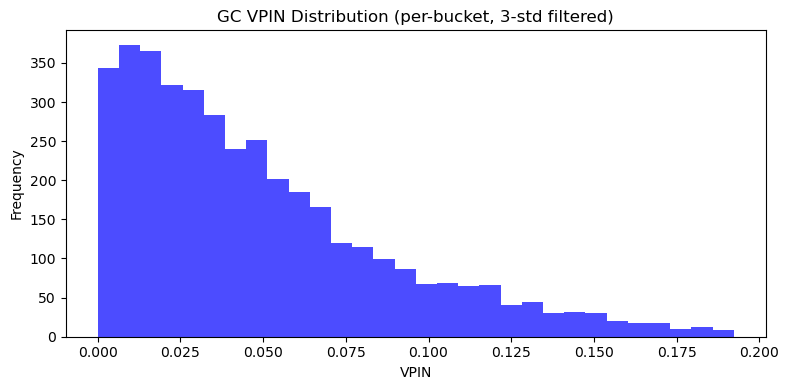

Saved gc_vpin_histogram_filtered.png


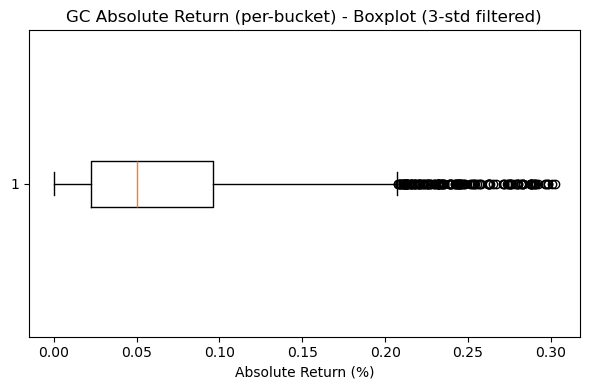

Saved gc_abs_return_boxplot_filtered.png


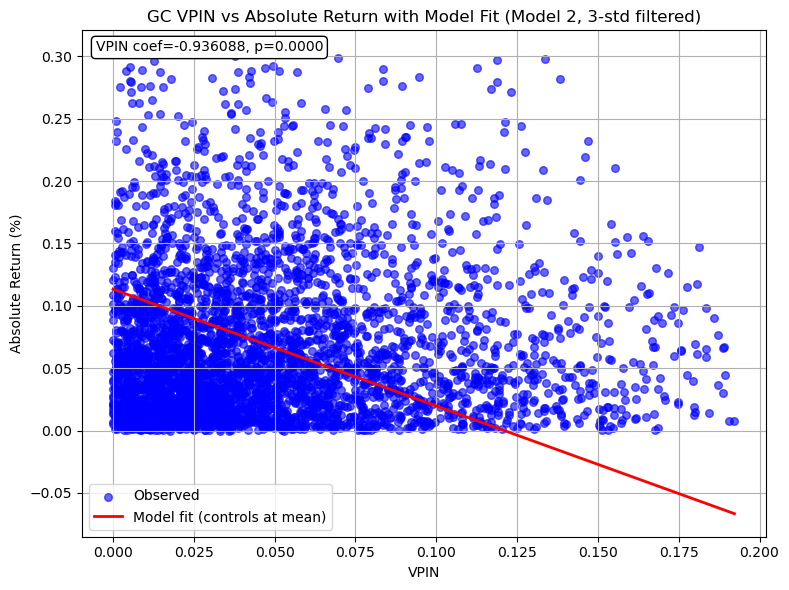

Saved gc_vpin_absreturn_model2_scatter_filtered.png


In [18]:
# Presentation graphs for GC: VPIN histogram, abs_return boxplot, scatter with model2 fit (3-std filtered)
import matplotlib.pyplot as plt
import numpy as np

gc_dfp = gc_df_reg.copy()

# GC VPIN histogram
fig = plt.figure(figsize=(8,4))
plt.hist(gc_dfp['VPIN_bucket'], bins=30, color='blue', alpha=0.7)
plt.xlabel('VPIN')
plt.ylabel('Frequency')
plt.title('GC VPIN Distribution (per-bucket, 3-std filtered)')
plt.tight_layout()
fig.savefig('gc_vpin_histogram_filtered.png', dpi=300)
plt.show()
print('Saved gc_vpin_histogram_filtered.png')

# GC abs_return boxplot
fig2 = plt.figure(figsize=(6,4))
plt.boxplot(gc_dfp['abs_return'].dropna(), vert=False)
plt.xlabel('Absolute Return (%)')
plt.title('GC Absolute Return (per-bucket) - Boxplot (3-std filtered)')
plt.tight_layout()
fig2.savefig('gc_abs_return_boxplot_filtered.png', dpi=300)
plt.show()
print('Saved gc_abs_return_boxplot_filtered.png')

# GC Scatter with model2 fitted line
fig3, ax = plt.subplots(figsize=(8,6))
ax.scatter(gc_dfp['VPIN_bucket'], gc_dfp['abs_return'], color='blue', alpha=0.6, s=30, label='Observed')

vpin_grid_gc = np.linspace(gc_dfp['VPIN_bucket'].min(), gc_dfp['VPIN_bucket'].max(), 100)
mean_spread_gc = gc_dfp['avg_spread'].mean()
mean_OI_gc = gc_dfp['OI'].mean()
gc_pred_df = pd.DataFrame({'VPIN_bucket': vpin_grid_gc, 'avg_spread': mean_spread_gc, 'OI': mean_OI_gc})
gc_pred_vals = gc_model2.predict(gc_pred_df)
ax.plot(vpin_grid_gc, gc_pred_vals, color='red', linewidth=2, label='Model fit (controls at mean)')

coef_text_gc = f"VPIN coef={gc_model2.params['VPIN_bucket']:.6f}, p={gc_model2.pvalues['VPIN_bucket']:.4f}"
ax.text(0.02, 0.98, coef_text_gc, transform=ax.transAxes, va='top', fontsize=10, bbox=dict(boxstyle='round', fc='w'))
ax.set_xlabel('VPIN')
ax.set_ylabel('Absolute Return (%)')
ax.set_title('GC VPIN vs Absolute Return with Model Fit (Model 2, 3-std filtered)')
ax.legend()
ax.grid(True)
plt.tight_layout()
fig3.savefig('gc_vpin_absreturn_model2_scatter_filtered.png', dpi=300)
plt.show()
print('Saved gc_vpin_absreturn_model2_scatter_filtered.png')


GC Regression Analysis: Remove Extremes (3 std) and Replot

GC Original data points: 4200
VPIN outliers (> 3 std): 67
Abs_return outliers (> 3 std): 68
Total outliers removed: 134
Clean data points: 4066

LINEAR REGRESSION (OUTLIERS REMOVED): GC VPIN → Volatility
Slope (coefficient): 0.061756
Intercept: 0.064767
R-squared: 0.001817
Correlation coefficient (r): 0.042629
P-value: 6.55e-03
Standard Error: 0.022704
Regression equation: abs_return = 0.064767 + 0.061756 * VPIN
Statistical significance: YES (p < 0.05) - SIGNIFICANT
Interpretation: A 1-unit increase in VPIN is associated with a 0.061756% change in absolute return.


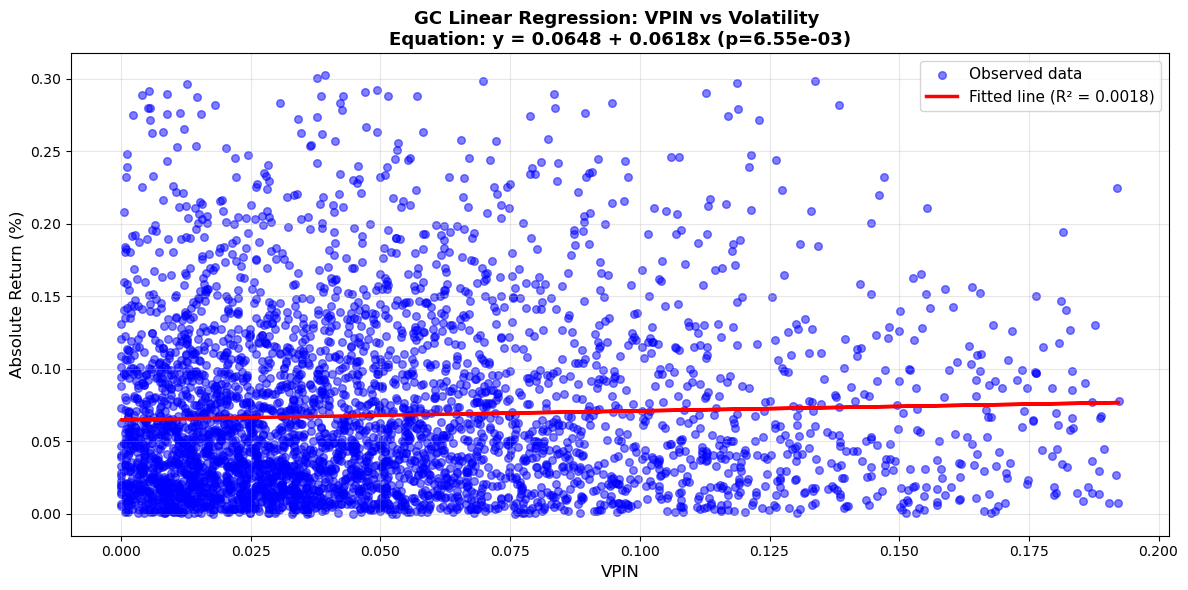


✓ Saved regression plot: gc_vpin_regression_volatility_no_outliers.png

Clean Data Statistics:
Mean of VPIN: 0.049714
Std of VPIN: 0.041248
Mean of abs_return: 0.067838
Std of abs_return: 0.059754
Min/Max VPIN: 0.000000 / 0.192321
Min/Max abs_return: 0.000000 / 0.302382


In [40]:
# Remove extremes (> 3 std from mean) and rerun regression for GC
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Prepare data: remove any NaN values
gc_reg_data = gc_buckets[['VPIN_bucket', 'abs_return']].dropna().copy()
print(f'GC Original data points: {len(gc_reg_data)}')

# Calculate mean and std for both variables
gc_vpin_mean = gc_reg_data['VPIN_bucket'].mean()
gc_vpin_std = gc_reg_data['VPIN_bucket'].std()
gc_absret_mean = gc_reg_data['abs_return'].mean()
gc_absret_std = gc_reg_data['abs_return'].std()

# Define threshold: 3 standard deviations
gc_threshold = 3

# Identify outliers
gc_vpin_outliers = (gc_reg_data['VPIN_bucket'] - gc_vpin_mean).abs() > gc_threshold * gc_vpin_std
gc_absret_outliers = (gc_reg_data['abs_return'] - gc_absret_mean).abs() > gc_threshold * gc_absret_std

gc_outlier_mask = gc_vpin_outliers | gc_absret_outliers
gc_n_outliers = gc_outlier_mask.sum()

print(f'VPIN outliers (> 3 std): {gc_vpin_outliers.sum()}')
print(f'Abs_return outliers (> 3 std): {gc_absret_outliers.sum()}')
print(f'Total outliers removed: {gc_n_outliers}')

# Remove outliers
gc_reg_data_clean = gc_reg_data[~gc_outlier_mask].copy()
print(f'Clean data points: {len(gc_reg_data_clean)}')

# Extract variables
gc_X = gc_reg_data_clean['VPIN_bucket'].values
gc_y = gc_reg_data_clean['abs_return'].values

# Fit linear regression using scipy
gc_slope, gc_intercept, gc_r_value, gc_p_value, gc_std_err = stats.linregress(gc_X, gc_y)

# Calculate R-squared
gc_r_squared = gc_r_value ** 2

# Generate predicted values
gc_y_pred = gc_intercept + gc_slope * gc_X

print('\n' + '='*60)
print('LINEAR REGRESSION (OUTLIERS REMOVED): GC VPIN → Volatility')
print('='*60)
print(f'Slope (coefficient): {gc_slope:.6f}')
print(f'Intercept: {gc_intercept:.6f}')
print(f'R-squared: {gc_r_squared:.6f}')
print(f'Correlation coefficient (r): {gc_r_value:.6f}')
print(f'P-value: {gc_p_value:.2e}')
print(f'Standard Error: {gc_std_err:.6f}')
print(f'Regression equation: abs_return = {gc_intercept:.6f} + {gc_slope:.6f} * VPIN')
print('='*60)

# Interpretation
if gc_p_value < 0.05:
    gc_sig = 'YES (p < 0.05) - SIGNIFICANT'
else:
    gc_sig = 'NO (p >= 0.05) - NOT SIGNIFICANT'
print(f'Statistical significance: {gc_sig}')
print(f'Interpretation: A 1-unit increase in VPIN is associated with a {gc_slope:.6f}% change in absolute return.')

# Create scatter plot with regression line (clean data)
fig, ax = plt.subplots(figsize=(12, 6))

# Scatter plot
ax.scatter(gc_X, gc_y, alpha=0.5, s=30, label='Observed data', color='blue')

# Regression line
ax.plot(gc_X, gc_y_pred, color='red', linewidth=2.5, label=f'Fitted line (R² = {gc_r_squared:.4f})')

# Labels and title
ax.set_xlabel('VPIN', fontsize=12)
ax.set_ylabel('Absolute Return (%)', fontsize=12)
ax.set_title(f'GC Linear Regression: VPIN vs Volatility \nEquation: y = {gc_intercept:.4f} + {gc_slope:.4f}x (p={gc_p_value:.2e})', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Save the plot
fig.savefig('gc_vpin_regression_volatility_no_outliers.png', dpi=300)
print(f'\n✓ Saved regression plot: gc_vpin_regression_volatility_no_outliers.png')

# Additional statistics (clean data)
print(f'\nClean Data Statistics:')
print(f'Mean of VPIN: {gc_X.mean():.6f}')
print(f'Std of VPIN: {gc_X.std():.6f}')
print(f'Mean of abs_return: {gc_y.mean():.6f}')
print(f'Std of abs_return: {gc_y.std():.6f}')
print(f'Min/Max VPIN: {gc_X.min():.6f} / {gc_X.max():.6f}')
print(f'Min/Max abs_return: {gc_y.min():.6f} / {gc_y.max():.6f}')

## GC HTC Data 

In [ ]:
# 1) Load GC_HTC_Updated.csv (gchc) — cell replicates original load step with new names
import pandas as pd

gchc = pd.read_csv('GC_HTC_Updated.csv', sep='\t', dtype=str)
print('gchc loaded — shape:', gchc.shape)
print('Columns:', list(gchc.columns)[:10])


In [ ]:
# 2) Clean GC HTC data and save `icm_gchc_final_cleaned.csv` (mirrors original clean cell)
import numpy as np

# Try to coerce Bid/Ask/VOLUME columns to numeric if present
for col in gchc.columns:
    if 'BID' in col.upper() or 'ASK' in col.upper() or 'VOLUME' in col.upper():
        gchc[col] = pd.to_numeric(gchc[col].str.strip(), errors='coerce')

# Detect date/time columns
date_col = next((c for c in gchc.columns if 'DATE' in c.upper()), None)
time_col = next((c for c in gchc.columns if 'TIME' in c.upper()), None)

if date_col is None:
    raise ValueError('No date column found in GC_HTC_Updated.csv')

# Parse date and filter from 2024-12-01
gchc[date_col] = pd.to_datetime(gchc[date_col], errors='coerce')
before_rows = len(gchc)
gchc = gchc[gchc[date_col] >= pd.Timestamp('2024-12-01')]
print(f'After date filter: {before_rows} -> {len(gchc)}')

# Time filtering (NY 09:30-16:00) if time present
if time_col:
    gchc[time_col] = gchc[time_col].astype(str).str.strip()
    combined = pd.to_datetime(gchc[date_col].dt.strftime('%Y-%m-%d') + ' ' + gchc[time_col], errors='coerce')
    try:
        combined = combined.dt.tz_localize('Europe/Bucharest', ambiguous='NaT', nonexistent='shift_forward')
        combined_ny = combined.dt.tz_convert('America/New_York')
        times_ny = combined_ny.dt.time
        mask_time = (times_ny >= pd.to_datetime('09:30').time()) & (times_ny <= pd.to_datetime('16:00').time())
        before_time = len(gchc)
        gchc = gchc[mask_time.fillna(False).values]
        print(f'After time filter: {before_time} -> {len(gchc)}')
    except Exception as e:
        print('Timezone conversion skipped due to:', e)

# Forward fill and select core columns
gchc = gchc.fillna(method='ffill')

# find bid/ask columns
bid_col = next((c for c in gchc.columns if 'BID' in c.upper()), None)
ask_col = next((c for c in gchc.columns if 'ASK' in c.upper()), None)
vol_col = next((c for c in gchc.columns if 'VOLUME' in c.upper()), None)

final_cols = [date_col]
if time_col: final_cols.append(time_col)
if bid_col: final_cols.append(bid_col)
if ask_col: final_cols.append(ask_col)

gchc_clean = gchc[final_cols].rename(columns={date_col:'Date', time_col:'Time', bid_col:'Bid', ask_col:'Ask'})

# Round
if 'Bid' in gchc_clean.columns: gchc_clean['Bid'] = gchc_clean['Bid'].round(3)
if 'Ask' in gchc_clean.columns: gchc_clean['Ask'] = gchc_clean['Ask'].round(3)

# Drop rows missing both
if set(['Bid','Ask']).issubset(gchc_clean.columns):
    gchc_clean = gchc_clean.dropna(subset=['Bid','Ask'], how='all')

out_icm = 'icm_gchc_final_cleaned.csv'
gchc_clean.to_csv(out_icm, index=False)
print('Saved', out_icm, 'shape:', gchc_clean.shape)


In [20]:
# 3) Load cleaned gchc CSV and compute Mid (separate cell)
import pandas as pd

gchc_c = pd.read_csv('HTC_GC_final_cleaned.csv')
print('icm_gchc_final_cleaned.csv loaded — shape:', gchc_c.shape)
if set(['Bid','Ask']).issubset(gchc_c.columns):
    gchc_c['Mid'] = (gchc_c['Bid'] + gchc_c['Ask']) / 2
    print('Added Mid column')
else:
    print('Bid/Ask missing in cleaned file; Mid not computed')

print(gchc_c.head())


icm_gchc_final_cleaned.csv loaded — shape: (18844917, 4)
Added Mid column
         Date          Time      Bid      Ask       Mid
0  2025-01-02  16:30:00.074  2646.39  2646.49  2646.440
1  2025-01-02  16:30:00.196  2646.44  2646.53  2646.485
2  2025-01-02  16:30:00.325  2646.49  2646.63  2646.560
3  2025-01-02  16:30:00.398  2646.83  2646.91  2646.870
4  2025-01-02  16:30:00.595  2646.80  2646.88  2646.840


In [21]:
# 4) Classify buys/sells for gchc_c (direction, BuyVolume, SellVolume)
import numpy as np

gchc_c['PrevMidPrice'] = gchc_c['Mid'].shift(1)

gchc_c['Direction'] = 0.0
gchc_c.loc[gchc_c['Mid'] > gchc_c['PrevMidPrice'], 'Direction'] = 1
gchc_c.loc[gchc_c['Mid'] < gchc_c['PrevMidPrice'], 'Direction'] = -1

gchc_c['Direction'] = gchc_c['Direction'].replace(0, np.nan).ffill().bfill()

gchc_c['BuyVolume'] = (gchc_c['Direction'] == 1).astype(float)
gchc_c['SellVolume'] = (gchc_c['Direction'] == -1).astype(float)

print('Direction counts:')
print(gchc_c['Direction'].value_counts())
print('BuyVolume sum:', gchc_c['BuyVolume'].sum(), 'SellVolume sum:', gchc_c['SellVolume'].sum())


Direction counts:
Direction
 1.0    9531194
-1.0    9313723
Name: count, dtype: int64
BuyVolume sum: 9531194.0 SellVolume sum: 9313723.0


In [22]:
# 5) Compute daily totals, V_d, buckets and VPIN for gchc_c — save gchc_buckets_50_per_day.csv

daily_volume_gchc = gchc_c.groupby('Date')[['BuyVolume','SellVolume']].sum().reset_index()
daily_volume_gchc['DailyTotalVolume'] = daily_volume_gchc['BuyVolume'] + daily_volume_gchc['SellVolume']
daily_volume_gchc['V_d'] = daily_volume_gchc['DailyTotalVolume'] / 50.0

# Attach per-row daily totals
gchc_c['Volume'] = gchc_c.get('Volume', gchc_c['BuyVolume'] + gchc_c['SellVolume'])
gchc_c['DailyTotalVolume'] = gchc_c.groupby('Date')['Volume'].transform('sum')
gchc_c['V_d'] = gchc_c['DailyTotalVolume'] / 50.0
gchc_c['V_d'] = gchc_c['V_d'].replace(0,1)

# Cumulative volume and bucket number
gchc_c['cum_vol'] = gchc_c.groupby('Date')['Volume'].cumsum()
# bucket_number as ceil(cum_vol / V_d)
gchc_c['bucket_number'] = np.ceil(gchc_c['cum_vol'] / gchc_c['V_d']).fillna(1).astype(int)
gchc_c['bucket_number'] = gchc_c['bucket_number'].clip(1,50)

# bucket aggregates via transform
gchc_c['bucket_buy_sum'] = gchc_c.groupby(['Date','bucket_number'])['BuyVolume'].transform('sum')
gchc_c['bucket_sell_sum'] = gchc_c.groupby(['Date','bucket_number'])['SellVolume'].transform('sum')
gchc_c['bucket_V'] = gchc_c.groupby(['Date','bucket_number'])['Volume'].transform('sum')

gchc_c['bucket_OI'] = gchc_c['bucket_buy_sum'] - gchc_c['bucket_sell_sum']
gchc_c['bucket_OI_abs'] = gchc_c['bucket_OI'].abs()

gchc_c['VPIN_bucket'] = gchc_c['bucket_OI_abs'] / gchc_c['V_d']

# Mark bucket end rows
gchc_c['pos_in_bucket'] = gchc_c.groupby(['Date','bucket_number']).cumcount()
gchc_c['bucket_size_ticks'] = gchc_c.groupby(['Date','bucket_number'])['Volume'].transform('size')
gchc_c['is_bucket_end'] = gchc_c['pos_in_bucket'] == (gchc_c['bucket_size_ticks'] - 1)

# Create bucket summary
gchc_buckets = gchc_c[gchc_c['is_bucket_end']].copy()[['Date','bucket_number','bucket_buy_sum','bucket_sell_sum','bucket_V','bucket_OI_abs','V_d','VPIN_bucket']]
gchc_buckets = gchc_buckets.rename(columns={'bucket_number':'bucket_idx','bucket_buy_sum':'buy','bucket_sell_sum':'sell','bucket_V':'V','bucket_OI_abs':'OI'})
gchc_buckets = gchc_buckets.sort_values(['Date','bucket_idx']).reset_index(drop=True)

gchc_buckets.to_csv('gchc_buckets_50_per_day.csv', index=False)
print('Saved gchc_buckets_50_per_day.csv — shape:', gchc_buckets.shape)


Saved gchc_buckets_50_per_day.csv — shape: (11800, 8)


In [23]:
# 6) Per-bucket metrics: opening_price, closing_price, abs_return, avg_spread -> save gchc_buckets_with_metrics.csv
metrics = []
for (day, bidx), group in gchc_c.groupby(['Date','bucket_number']):
    if group.empty:
        continue
    opening = group['Mid'].iloc[0]
    closing = group['Mid'].iloc[-1]
    absret = abs((closing - opening) / opening * 100) if opening != 0 else np.nan
    if set(['Ask','Bid']).issubset(group.columns):
        spread = (group['Ask'] - group['Bid']).mean()
    else:
        spread = np.nan
    metrics.append({'Date': day, 'bucket_idx': bidx, 'opening_price': opening, 'closing_price': closing, 'abs_return': absret, 'avg_spread': spread})

metrics_df = pd.DataFrame(metrics)
if not metrics_df.empty:
    gchc_buckets = gchc_buckets.merge(metrics_df, on=['Date','bucket_idx'], how='left')

gchc_buckets.to_csv('gchc_buckets_with_metrics.csv', index=False)
print('Saved gchc_buckets_with_metrics.csv — shape:', gchc_buckets.shape)


Saved gchc_buckets_with_metrics.csv — shape: (11800, 12)


In [24]:
# 7) Filter >3 std outliers (combined) and save descriptive stats & correlations
cols_to_filter = ['VPIN_bucket','abs_return','avg_spread','OI']

gchc_filtered_work = gchc_buckets[cols_to_filter].dropna().copy()
means = gchc_filtered_work.mean()
stds = gchc_filtered_work.std()

outlier_masks = {c: (gchc_filtered_work[c] - means[c]).abs() > 3*stds[c] for c in cols_to_filter}
combined_mask = pd.concat(outlier_masks, axis=1).any(axis=1)

print('Outliers per col:')
for c in cols_to_filter:
    print(c, outlier_masks[c].sum())
print('Total combined outliers:', combined_mask.sum())

gchc_buckets_filtered = gchc_buckets.loc[~combined_mask.values].reset_index(drop=True)
gchc_buckets_filtered.to_csv('gchc_descriptive_stats_buckets_filtered.csv', index=False)
print('Saved gchc_descriptive_stats_buckets_filtered.csv — shape:', gchc_buckets_filtered.shape)

# Correlation
gchc_corr = gchc_buckets_filtered[cols_to_filter].corr().round(4)
gchc_corr.to_csv('gchc_correlation_matrix_buckets_filtered.csv')
print('Saved gchc_correlation_matrix_buckets_filtered.csv')

gchc_desc_df = gchc_buckets_filtered[cols_to_filter].describe(percentiles=[.25,.5,.75]).T
print(gchc_desc_df)

gchc_desc_df.to_csv('gchc_descriptive_stats_buckets_filtered.csv')
print('Saved descriptive stats CSV')


Outliers per col:
VPIN_bucket 232
abs_return 202
avg_spread 182
OI 264
Total combined outliers: 736
Saved gchc_descriptive_stats_buckets_filtered.csv — shape: (11064, 12)
Saved gchc_correlation_matrix_buckets_filtered.csv
               count       mean        std   min        25%        50%  \
VPIN_bucket  11064.0   0.047116   0.038240  0.00   0.017940   0.037634   
abs_return   11064.0   0.059819   0.051328  0.00   0.020889   0.045502   
avg_spread   11064.0   0.094538   0.017306  0.07   0.083276   0.092041   
OI           11064.0  72.580803  61.861355  0.00  26.000000  56.000000   

                    75%         max  
VPIN_bucket    0.065794    0.194069  
abs_return     0.084468    0.266697  
avg_spread     0.100484    0.176193  
OI           101.000000  329.000000  
Saved descriptive stats CSV


In [25]:
# 8) OLS regressions (Model1 & Model2) with HC3 on filtered GC HTC data
import statsmodels.formula.api as smf

gchc_df_reg = gchc_buckets_filtered[['VPIN_bucket','abs_return','avg_spread','OI']].dropna().copy()
print('Regression sample size:', len(gchc_df_reg))

if len(gchc_df_reg) > 0:
    gchc_model1 = smf.ols('abs_return ~ VPIN_bucket', data=gchc_df_reg).fit(cov_type='HC3')
    with open('gchc_ols_model1_summary_filtered.txt','w') as f:
        f.write(gchc_model1.summary().as_text())
    print('Saved gchc_ols_model1_summary_filtered.txt')

    gchc_model2 = smf.ols('abs_return ~ VPIN_bucket + avg_spread + OI', data=gchc_df_reg).fit(cov_type='HC3')
    with open('gchc_ols_model2_summary_filtered.txt','w') as f:
        f.write(gchc_model2.summary().as_text())
    print('Saved gchc_ols_model2_summary_filtered.txt')

    gchc_coefs = pd.DataFrame({'coef': gchc_model2.params, 'std_err': gchc_model2.bse, 'pvalue': gchc_model2.pvalues}).round(6)
    gchc_coefs.to_csv('gchc_model2_coefficients_filtered.csv')
    print('Saved gchc_model2_coefficients_filtered.csv')
else:
    print('Not enough rows for regression')


Regression sample size: 11064
Saved gchc_ols_model1_summary_filtered.txt
Saved gchc_ols_model2_summary_filtered.txt
Saved gchc_model2_coefficients_filtered.csv


In [26]:
# 9) Presentation plots for GC HTC filtered data (histogram, boxplot, scatter with model2 fit)
import matplotlib.pyplot as plt

if 'gchc_df_reg' in globals() and len(gchc_df_reg) > 0:
    # Histogram
    fig = plt.figure(figsize=(8,4))
    plt.hist(gchc_df_reg['VPIN_bucket'].dropna(), bins=30, color='blue', alpha=0.7)
    plt.xlabel('VPIN')
    plt.title('GC_HTC VPIN Distribution (per-bucket, 3-std filtered)')
    plt.tight_layout()
    fig.savefig('gchc_vpin_histogram_filtered.png', dpi=300)
    plt.close(fig)
    print('Saved gchc_vpin_histogram_filtered.png')

    # Boxplot
    fig2 = plt.figure(figsize=(6,4))
    plt.boxplot(gchc_df_reg['abs_return'].dropna(), vert=False)
    plt.xlabel('Absolute Return (%)')
    plt.title('GC_HTC Absolute Return (per-bucket) - Boxplot (3-std filtered)')
    plt.tight_layout()
    fig2.savefig('gchc_abs_return_boxplot_filtered.png', dpi=300)
    plt.close(fig2)
    print('Saved gchc_abs_return_boxplot_filtered.png')

    # Scatter with model fit
    if 'gchc_model2' in globals():
        fig3, ax = plt.subplots(figsize=(8,6))
        ax.scatter(gchc_df_reg['VPIN_bucket'], gchc_df_reg['abs_return'], color='blue', alpha=0.6, s=30, label='Observed')
        vpin_grid = np.linspace(gchc_df_reg['VPIN_bucket'].min(), gchc_df_reg['VPIN_bucket'].max(), 100)
        mean_spread = gchc_df_reg['avg_spread'].mean()
        mean_OI = gchc_df_reg['OI'].mean()
        pred_df = pd.DataFrame({'VPIN_bucket': vpin_grid, 'avg_spread': mean_spread, 'OI': mean_OI})
        pred_vals = gchc_model2.predict(pred_df)
        ax.plot(vpin_grid, pred_vals, color='red', linewidth=2, label='Model fit (controls at mean)')
        ax.set_xlabel('VPIN')
        ax.set_ylabel('Absolute Return (%)')
        ax.set_title('GC_HTC VPIN vs Absolute Return with Model Fit (Model 2)')
        ax.legend()
        plt.tight_layout()
        fig3.savefig('gchc_vpin_absreturn_model2_scatter_filtered.png', dpi=300)
        plt.close(fig3)
        print('Saved gchc_vpin_absreturn_model2_scatter_filtered.png')
else:
    print('No filtered regression dataframe available for plotting')

print('GC HTC section added — you can run the cells individually in order.')

Saved gchc_vpin_histogram_filtered.png
Saved gchc_abs_return_boxplot_filtered.png
Saved gchc_vpin_absreturn_model2_scatter_filtered.png
GC HTC section added — you can run the cells individually in order.


## NQ HTC Data Analysis (NQ_HTC_Updated.csv)

In [ ]:
# 1) Load NQ_HTC_Updated.csv into `nqhtc`
import pandas as pd

nqhtc = pd.read_csv('NQ_HTC_Updated.csv', sep='\t', dtype=str)
print('nqhtc loaded — shape:', nqhtc.shape)
print('Columns preview:', list(nqhtc.columns)[:10])

In [ ]:
# 2) Clean NQ HTC data and save `icm_nqhtc_final_cleaned.csv`
import numpy as np

# Coerce numeric columns if present
for col in nqhtc.columns:
    if 'BID' in col.upper() or 'ASK' in col.upper() or 'VOLUME' in col.upper():
        nqhtc[col] = pd.to_numeric(nqhtc[col].str.strip(), errors='coerce')

# Detect date/time columns
date_col = next((c for c in nqhtc.columns if 'DATE' in c.upper()), None)
time_col = next((c for c in nqhtc.columns if 'TIME' in c.upper()), None)
if date_col is None:
    raise ValueError('No date column in NQ_HTC_Updated.csv')

# Parse date and filter
nqhtc[date_col] = pd.to_datetime(nqhtc[date_col], errors='coerce')
before_rows = len(nqhtc)
nqhtc = nqhtc[nqhtc[date_col] >= pd.Timestamp('2024-12-01')]
print(f'After date filter: {before_rows} -> {len(nqhtc)}')

# Time filter if present
if time_col:
    nqhtc[time_col] = nqhtc[time_col].astype(str).str.strip()
    combined = pd.to_datetime(nqhtc[date_col].dt.strftime('%Y-%m-%d') + ' ' + nqhtc[time_col], errors='coerce')
    try:
        combined = combined.dt.tz_localize('Europe/Bucharest', ambiguous='NaT', nonexistent='shift_forward')
        combined_ny = combined.dt.tz_convert('America/New_York')
        times_ny = combined_ny.dt.time
        mask_time = (times_ny >= pd.to_datetime('09:30').time()) & (times_ny <= pd.to_datetime('16:00').time())
        before_time = len(nqhtc)
        nqhtc = nqhtc[mask_time.fillna(False).values]
        print(f'After time filter: {before_time} -> {len(nqhtc)}')
    except Exception as e:
        print('Timezone conversion skipped due to:', e)

# Forward fill and pick core cols
nqhtc = nqhtc.fillna(method='ffill')

bid_col = next((c for c in nqhtc.columns if 'BID' in c.upper()), None)
ask_col = next((c for c in nqhtc.columns if 'ASK' in c.upper()), None)
vol_col = next((c for c in nqhtc.columns if 'VOLUME' in c.upper()), None)

final_cols = [date_col]
if time_col: final_cols.append(time_col)
if bid_col: final_cols.append(bid_col)
if ask_col: final_cols.append(ask_col)

nqhtc_clean = nqhtc[final_cols].rename(columns={date_col:'Date', time_col:'Time', bid_col:'Bid', ask_col:'Ask'})

if 'Bid' in nqhtc_clean.columns: nqhtc_clean['Bid'] = nqhtc_clean['Bid'].round(3)
if 'Ask' in nqhtc_clean.columns: nqhtc_clean['Ask'] = nqhtc_clean['Ask'].round(3)

if set(['Bid','Ask']).issubset(nqhtc_clean.columns):
    nqhtc_clean = nqhtc_clean.dropna(subset=['Bid','Ask'], how='all')

out_icm_nqhtc = 'icm_nqhtc_final_cleaned.csv'
nqhtc_clean.to_csv(out_icm_nqhtc, index=False)
print('Saved', out_icm_nqhtc, 'shape:', nqhtc_clean.shape)

In [27]:
# 3) Load cleaned nqhtc CSV and compute Mid
import pandas as pd

nqhtc_c = pd.read_csv('HTC_nq_final_cleaned.csv')
print('icm_nqhtc_final_cleaned.csv loaded — shape:', nqhtc_c.shape)
if set(['Bid','Ask']).issubset(nqhtc_c.columns):
    nqhtc_c['Mid'] = (nqhtc_c['Bid'] + nqhtc_c['Ask']) / 2
    print('Added Mid column')
else:
    print('Bid/Ask missing; Mid not computed')

print(nqhtc_c.head())

icm_nqhtc_final_cleaned.csv loaded — shape: (26858059, 4)
Added Mid column
         Date          Time       Bid       Ask       Mid
0  2025-01-02  16:30:00.197  21095.74  21096.34  21096.04
1  2025-01-02  16:30:00.327  21093.49  21094.09  21093.79
2  2025-01-02  16:30:00.534  21091.49  21092.09  21091.79
3  2025-01-02  16:30:00.634  21088.74  21089.34  21089.04
4  2025-01-02  16:30:01.273  21088.37  21088.97  21088.67


In [ ]:
# 4) Classify buys/sells for nqhtc_c
import numpy as np

nqhtc_c['PrevMidPrice'] = nqhtc_c['Mid'].shift(1)

nqhtc_c['Direction'] = 0.0
nqhtc_c.loc[nqhtc_c['Mid'] > nqhtc_c['PrevMidPrice'], 'Direction'] = 1
nqhtc_c.loc[nqhtc_c['Mid'] < nqhtc_c['PrevMidPrice'], 'Direction'] = -1
nqhtc_c['Direction'] = nqhtc_c['Direction'].replace(0, np.nan).ffill().bfill()

nqhtc_c['BuyVolume'] = (nqhtc_c['Direction'] == 1).astype(float)
nqhtc_c['SellVolume'] = (nqhtc_c['Direction'] == -1).astype(float)

print('Direction counts:')
print(nqhtc_c['Direction'].value_counts())
print('BuyVolume sum:', nqhtc_c['BuyVolume'].sum(), 'SellVolume sum:', nqhtc_c['SellVolume'].sum())

In [ ]:
# 5) Daily totals, V_d, buckets and VPIN for nqhtc_c -> save nqhtc_buckets_50_per_day.csv

daily_volume_nqhtc = nqhtc_c.groupby('Date')[['BuyVolume','SellVolume']].sum().reset_index()
daily_volume_nqhtc['DailyTotalVolume'] = daily_volume_nqhtc['BuyVolume'] + daily_volume_nqhtc['SellVolume']
daily_volume_nqhtc['V_d'] = daily_volume_nqhtc['DailyTotalVolume'] / 50.0

nqhtc_c['Volume'] = nqhtc_c.get('Volume', nqhtc_c['BuyVolume'] + nqhtc_c['SellVolume'])
nqhtc_c['DailyTotalVolume'] = nqhtc_c.groupby('Date')['Volume'].transform('sum')
nqhtc_c['V_d'] = nqhtc_c['DailyTotalVolume'] / 50.0
nqhtc_c['V_d'] = nqhtc_c['V_d'].replace(0,1)

nqhtc_c['cum_vol'] = nqhtc_c.groupby('Date')['Volume'].cumsum()
nqhtc_c['bucket_number'] = np.ceil(nqhtc_c['cum_vol'] / nqhtc_c['V_d']).fillna(1).astype(int)
nqhtc_c['bucket_number'] = nqhtc_c['bucket_number'].clip(1,50)

nqhtc_c['bucket_buy_sum'] = nqhtc_c.groupby(['Date','bucket_number'])['BuyVolume'].transform('sum')
nqhtc_c['bucket_sell_sum'] = nqhtc_c.groupby(['Date','bucket_number'])['SellVolume'].transform('sum')
nqhtc_c['bucket_V'] = nqhtc_c.groupby(['Date','bucket_number'])['Volume'].transform('sum')

nqhtc_c['bucket_OI'] = nqhtc_c['bucket_buy_sum'] - nqhtc_c['bucket_sell_sum']
nqhtc_c['bucket_OI_abs'] = nqhtc_c['bucket_OI'].abs()

nqhtc_c['VPIN_bucket'] = nqhtc_c['bucket_OI_abs'] / nqhtc_c['V_d']

nqhtc_c['pos_in_bucket'] = nqhtc_c.groupby(['Date','bucket_number']).cumcount()
nqhtc_c['bucket_size_ticks'] = nqhtc_c.groupby(['Date','bucket_number'])['Volume'].transform('size')
nqhtc_c['is_bucket_end'] = nqhtc_c['pos_in_bucket'] == (nqhtc_c['bucket_size_ticks'] - 1)

nqhtc_buckets = nqhtc_c[nqhtc_c['is_bucket_end']].copy()[['Date','bucket_number','bucket_buy_sum','bucket_sell_sum','bucket_V','bucket_OI_abs','V_d','VPIN_bucket']]
nqhtc_buckets = nqhtc_buckets.rename(columns={'bucket_number':'bucket_idx','bucket_buy_sum':'buy','bucket_sell_sum':'sell','bucket_V':'V','bucket_OI_abs':'OI'})
nqhtc_buckets = nqhtc_buckets.sort_values(['Date','bucket_idx']).reset_index(drop=True)

nqhtc_buckets.to_csv('nqhtc_buckets_50_per_day.csv', index=False)
print('Saved nqhtc_buckets_50_per_day.csv — shape:', nqhtc_buckets.shape)

In [ ]:
# 6) Per-bucket metrics and save nqhtc_buckets_with_metrics.csv
metrics = []
for (day, bidx), group in nqhtc_c.groupby(['Date','bucket_number']):
    if group.empty:
        continue
    opening = group['Mid'].iloc[0]
    closing = group['Mid'].iloc[-1]
    absret = abs((closing - opening) / opening * 100) if opening != 0 else np.nan
    if set(['Ask','Bid']).issubset(group.columns):
        spread = (group['Ask'] - group['Bid']).mean()
    else:
        spread = np.nan
    metrics.append({'Date': day, 'bucket_idx': bidx, 'opening_price': opening, 'closing_price': closing, 'abs_return': absret, 'avg_spread': spread})

metrics_df = pd.DataFrame(metrics)
if not metrics_df.empty:
    nqhtc_buckets = nqhtc_buckets.merge(metrics_df, on=['Date','bucket_idx'], how='left')

nqhtc_buckets.to_csv('nqhtc_buckets_with_metrics.csv', index=False)
print('Saved nqhtc_buckets_with_metrics.csv — shape:', nqhtc_buckets.shape)

In [ ]:
# 7) Filter >3 std outliers and save descriptive stats & correlation for NQ HTC
cols_to_filter_nq = ['VPIN_bucket','abs_return','avg_spread','OI']

nqhtc_filtered_work = nqhtc_buckets[cols_to_filter_nq].dropna().copy()
means_nq = nqhtc_filtered_work.mean()
stds_nq = nqhtc_filtered_work.std()

outlier_masks_nq = {c: (nqhtc_filtered_work[c] - means_nq[c]).abs() > 3*stds_nq[c] for c in cols_to_filter_nq}
combined_mask_nq = pd.concat(outlier_masks_nq, axis=1).any(axis=1)

print('Outliers per col (nq):')
for c in cols_to_filter_nq:
    print(c, outlier_masks_nq[c].sum())
print('Total combined outliers (nq):', combined_mask_nq.sum())

nqhtc_buckets_filtered = nqhtc_buckets.loc[~combined_mask_nq.values].reset_index(drop=True)
nqhtc_buckets_filtered.to_csv('nqhtc_descriptive_stats_buckets_filtered.csv', index=False)
print('Saved nqhtc_descriptive_stats_buckets_filtered.csv — shape:', nqhtc_buckets_filtered.shape)

nqhtc_corr = nqhtc_buckets_filtered[cols_to_filter_nq].corr().round(4)
nqhtc_corr.to_csv('nqhtc_correlation_matrix_buckets_filtered.csv')
print('Saved nqhtc_correlation_matrix_buckets_filtered.csv')

nqhtc_desc_df = nqhtc_buckets_filtered[cols_to_filter_nq].describe(percentiles=[.25,.5,.75]).T
nqhtc_desc_df.to_csv('nqhtc_descriptive_stats_buckets_filtered.csv')
print('Saved nqhtc descriptive stats CSV')

In [ ]:
# 8) OLS regressions (Model1 & Model2) with HC3 for NQ HTC
import statsmodels.formula.api as smf

nqhtc_df_reg = nqhtc_buckets_filtered[['VPIN_bucket','abs_return','avg_spread','OI']].dropna().copy()
print('NQHTC regression sample size:', len(nqhtc_df_reg))

if len(nqhtc_df_reg) > 0:
    nqhtc_model1 = smf.ols('abs_return ~ VPIN_bucket', data=nqhtc_df_reg).fit(cov_type='HC3')
    with open('nqhtc_ols_model1_summary_filtered.txt','w') as f:
        f.write(nqhtc_model1.summary().as_text())
    print('Saved nqhtc_ols_model1_summary_filtered.txt')

    nqhtc_model2 = smf.ols('abs_return ~ VPIN_bucket + avg_spread + OI', data=nqhtc_df_reg).fit(cov_type='HC3')
    with open('nqhtc_ols_model2_summary_filtered.txt','w') as f:
        f.write(nqhtc_model2.summary().as_text())
    print('Saved nqhtc_ols_model2_summary_filtered.txt')

    nqhtc_coefs = pd.DataFrame({'coef': nqhtc_model2.params, 'std_err': nqhtc_model2.bse, 'pvalue': nqhtc_model2.pvalues}).round(6)
    nqhtc_coefs.to_csv('nqhtc_model2_coefficients_filtered.csv')
    print('Saved nqhtc_model2_coefficients_filtered.csv')
else:
    print('Not enough rows for NQHTC regression')

In [ ]:
# 9) Presentation plots for NQ HTC filtered data (histogram, boxplot, scatter with model2 fit)
import matplotlib.pyplot as plt

if 'nqhtc_df_reg' in globals() and len(nqhtc_df_reg) > 0:
    # Histogram
    fig = plt.figure(figsize=(8,4))
    plt.hist(nqhtc_df_reg['VPIN_bucket'].dropna(), bins=30, color='blue', alpha=0.7)
    plt.xlabel('VPIN')
    plt.title('NQ_HTC VPIN Distribution (per-bucket, 3-std filtered)')
    plt.tight_layout()
    fig.savefig('nqhtc_vpin_histogram_filtered.png', dpi=300)
    plt.close(fig)
    print('Saved nqhtc_vpin_histogram_filtered.png')

    # Boxplot
    fig2 = plt.figure(figsize=(6,4))
    plt.boxplot(nqhtc_df_reg['abs_return'].dropna(), vert=False)
    plt.xlabel('Absolute Return (%)')
    plt.title('NQ_HTC Absolute Return (per-bucket) - Boxplot (3-std filtered)')
    plt.tight_layout()
    fig2.savefig('nqhtc_abs_return_boxplot_filtered.png', dpi=300)
    plt.close(fig2)
    print('Saved nqhtc_abs_return_boxplot_filtered.png')

    # Scatter with model fit
    if 'nqhtc_model2' in globals():
        fig3, ax = plt.subplots(figsize=(8,6))
        ax.scatter(nqhtc_df_reg['VPIN_bucket'], nqhtc_df_reg['abs_return'], color='blue', alpha=0.6, s=30, label='Observed')
        vpin_grid = np.linspace(nqhtc_df_reg['VPIN_bucket'].min(), nqhtc_df_reg['VPIN_bucket'].max(), 100)
        mean_spread = nqhtc_df_reg['avg_spread'].mean()
        mean_OI = nqhtc_df_reg['OI'].mean()
        pred_df = pd.DataFrame({'VPIN_bucket': vpin_grid, 'avg_spread': mean_spread, 'OI': mean_OI})
        pred_vals = nqhtc_model2.predict(pred_df)
        ax.plot(vpin_grid, pred_vals, color='red', linewidth=2, label='Model fit (controls at mean)')
        ax.set_xlabel('VPIN')
        ax.set_ylabel('Absolute Return (%)')
        ax.set_title('NQ_HTC VPIN vs Absolute Return with Model Fit (Model 2)')
        ax.legend()
        plt.tight_layout()
        fig3.savefig('nqhtc_vpin_absreturn_model2_scatter_filtered.png', dpi=300)
        plt.close(fig3)
        print('Saved nqhtc_vpin_absreturn_model2_scatter_filtered.png')
else:
    print('No filtered regression dataframe available for NQ plotting')

print('NQ HTC section added — run cells 1..9 in order to process the file.')